# Silent Killer: A Stealthy, Clean-Label, Black-Box Backdoor Attack
### `silentkiller_finalNB.ipynb` — fixed per `silentkiller_required_fixes_v2.md`

This is a redo of `silent_killer_colab.ipynb` with every item in
`silentkiller_required_fixes_v2.md` applied: the critical config bugs (§1),
the reproducibility/team-integration items (§2), the structural patterns
borrowed from `blended_finalNB.ipynb` (§3), and the three decisions made
since v1 (§0 of that doc — trigger-crafting policy, Attention Correlation as
the TAR substitute, and the SK-only 0.5% poison rate).

## Notebook Index — Silent Killer Backdoor Attack (`silentkiller_finalNB.ipynb`)

| Section | What it does | Fix(es) applied |
|---|---|---|
| **0. Decisions Locked In This Revision** | Short recap of Decisions 1-3 from `silentkiller_required_fixes_v2.md` S0, read before running anything | -- |
| **1. Setup** | pip install, mount Drive + clone repo, core imports, reproducibility + global constants, shared indices, transforms | Imports `core.models`/`core.metrics`/`core.detection` instead of reimplementing |
| **2. Legacy SK Utilities** | Attack-specific helpers not covered by `core/`: device/optimizer/loss helpers, `Mixup`, logging | Unchanged from v1, kept local since these are SK-specific |
| **3. Dataset Classes** | `PoisonedSubset`, `PoisonedDataset`, `TriggeredDataset`, `TriggerAdditive`, `TriggerAdaptivePatch` | Unchanged -- `TRIGGER_TYPE='additive'` confirmed correct, kept |
| **4. Model Definitions** | `get_model()` dispatch | **Fix:** local ImageNet-stem `resnet18()` deleted; `'resnet18'` now resolves to `core.models.get_resnet18` (CIFAR stem) |
| **5. Trigger Optimisation** | Gradient-alignment trigger crafting functions | Unchanged from v1 |
| **6. Poison Crafting (`PoisonCrafter`)** | Gradient-matching poison crafting class | Unchanged logic, now instantiated via the CIFAR-stem model |
| **7. Training (`Trainer`)** | Generic training loop | Unchanged |
| **8. Shared Metrics** | `evaluate_poisoning_v2()` | **Fix:** ASR/CA now computed via `core.metrics.calculate_asr`/`calculate_ca` instead of the local accuracy loop |
| **9. Detection via `core/detection.py`** | Thin wrappers around `run_ac`, `run_strip`, `extract_activations` | **Fix:** inline `activation_clustering`/`filter_poison` removed entirely, replaced with the shared implementation |
| **10. Config** | `SEED`, class labels, poison rates, trigger/crafting hyperparameters, paths | **Fix:** `TARGET_LABEL=0` / `SOURCE_LABEL=3` (was reversed); poison-rate list now `[0.5%, 1%, 5%, 10%]`; new checkpoint/index naming scheme |
| **11. Experiment Setup** | Device, output dirs, CIFAR-10 load, config/defences dicts, summary printout | Adapted from v1 |
| **12. Clean Baseline + Clean-Source Model** | Two separate checkpoints | **Fix:** resolves the open "source vs. baseline" question -- mirrors the LC resolution in `01_SYSTEM_ARCHITECTURE.md` exactly |
| **13. Decision 1 Pilot (1% gate)** | Crafts the trigger once at 1%, trains, evaluates, gates Option A (shared trigger) vs. Option B (per-rate trigger) | Implements Decision 1 from the fixes doc, not left as a TODO |
| **14. Main Sweep -- 0.5% / 1% / 5% / 10%** | Nested, resumable, Drive-first per-rate poisoning + training | **Fix:** nesting enforced via prefix-sliced gradient ranking; SK-only 0.5% rate added (Decision 3) |
| **15. Sub-1% / Low-Count Arm** | `LOWRATE_COUNTS = [1,2,5,10,15,25]`, mirrors Blended's low-rate arm | New -- mirrors Blended structural pattern |
| **16. Trigger-Parameter Consistency Assertion** | Hard assertion that ASR-eval params and STRIP-pool params agree | Implements the "add an assertion, not just a convention" fix, to preempt a Blended-pr10-style silent mismatch |
| **17. Activation Clustering (AC)** | `run_ac` over main sweep + low-count arm, PCA-2D vs. ICA-10D | Routed through `core/detection.py` |
| **18. STRIP** | `run_strip` over main sweep + low-count arm, with the consistency assertion wired in | Routed through `core/detection.py` |
| **19. Attention Correlation (Grad-CAM)** | SK's TAR substitute -- Pearson correlation of clean vs. triggered Grad-CAM heatmaps | Implements Decision 2 (global trigger has no bounding box, so TAR doesn't apply) |
| **20. Results Summary + Save Outputs** | CA/ASR table per rate, CSV + JSON export | Adapted from v1 |
| **21. Visualizations** | Trigger pattern, clean-vs-poisoned samples | Adapted from v1 |
| **22. Closing Notes / Locked Decisions** | Records seed, classes, trigger variant, DR-method status, source-model decision, and the Decision-1 gate outcome (with pilot ASR) | **Fix:** required closing cell per S3 of the fixes doc |

**Fresh-session quick start:** run Sections 1-4 + 10-13 to reproduce the pilot gate decision, then Section 14 for the full sweep. If checkpoints already exist on Drive, every per-rate cell in Sections 14-15 loads instead of retraining.

---
## Section 0 — Decisions Locked In This Revision (read this first)

**Decision 1 — Trigger-crafting policy (gated Option A):** craft the trigger
delta once against the 1% poison budget, train that checkpoint, and check its
ASR. If it's reasonable (clearly above chance, ideally comparable to
Blended's ~100% at matched strength) -> **lock Option A**: reuse the same
trigger across 0.5%/5%/10% (one crafting run total, nesting preserved
automatically). If it's weak -> **fall back to Option B**: craft
independently per rate and document the nesting-property deviation. This
notebook implements the gate in Section 13 rather than assuming the answer.

**Decision 2 — Attention Correlation replaces TAR:** Silent Killer's trigger
is a global additive perturbation (no bounding box), so TAR as defined in
`05_DETECTION_AND_VERIFICATION.md` doesn't apply -- same situation as
Blended. Section 19 computes Pearson correlation between clean and triggered
Grad-CAM heatmaps instead.

**Decision 3 — 0.5% poison rate is SK-only:** not retrofitted onto BadNets or
Blended (both fully trained/confirmed already); added here because SK hasn't
been trained yet and the marginal cost is near-zero. Probes the lower bound
of AC's detection floor.

**Already correct, not touched:** `TRIGGER_TYPE = 'additive'` (global UAP
perturbation) is implemented correctly in the original notebook and is kept
as-is.

---
## Section 1 — Setup

In [ ]:
# # ════════════════════════════════════════════════════════════════════════════
# # Install Dependencies
# # ════════════════════════════════════════════════════════════════════════════
# !pip install -q numpy>=1.23.3 pandas>=1.5.1 torch>=1.12.1 \
#     torchvision>=0.13.1 tqdm>=4.64.1 "opencv-python>=4.6.0.66" \
#     matplotlib>=3.5.2 pillow>=9.2.0 scikit-learn>=1.1.2 scipy>=1.9.0
# print("All dependencies installed.")

In [ ]:
# # ════════════════════════════════════════════════════════════════════════════
# # [Kaggle-compat] Setup: clone repo + restore pre-existing artifacts
# # Replaces Colab's Drive mount. Two things this handles that a naive
# # `DRIVE_ROOT = '/kaggle/working/sk'` swap misses:
# #   1. Kaggle input datasets are READ-ONLY, but this notebook writes new
# #      checkpoints as it runs -- so pre-existing artifacts (defense_indices,
# #      asr_test_idx, the already-locked shared trigger, nested_ranking, and
# #      any checkpoints already produced in earlier Colab sessions: pr005/pr01,
# #      canonical clean baseline, SK clean-source model) get copied ONCE from
# #      the attached read-only input dataset into a writable working dir.
# #   2. Skipping step 1 means either a hard crash on the defense_indices
# #      assert two cells down, or -- worse -- silent re-crafting/re-training
# #      of everything from scratch, discarding all already-validated progress
# #      (including the locked Decision-1 shared trigger).
# #
# # ── ONE-TIME SETUP (do this before "Save & Run All") ──────────────────────
# # On the machine where your Drive is mounted, download the entire contents
# # of MyDrive/ps-capstone/sk/ (checkpoints, .npy index files, the shared
# # trigger, nested_ranking, crafting_metadata.csv -- everything) and upload
# # that folder as a new Kaggle Dataset. Then in this notebook: "+ Add Input"
# # -> search your dataset -> Add. Update _KAGGLE_INPUT_ARTIFACTS below to
# # match its actual mount path (visible under /kaggle/input/<your-dataset-slug>).
# # ════════════════════════════════════════════════════════════════════════════
# import os, shutil

# !git clone https://github.com/Aritraghoshdastidar/adaptive-backdoor-defense.git
# %cd adaptive-backdoor-defense

# DRIVE_ROOT = '/kaggle/working/sk'
# os.makedirs(DRIVE_ROOT, exist_ok=True)

# _KAGGLE_INPUT_ARTIFACTS = '/kaggle/input/datasets/archie29/silent-killer/sk'  # <-- adjust to your dataset's actual path

# if os.path.isdir(_KAGGLE_INPUT_ARTIFACTS):
#     _restored = 0
#     for fname in os.listdir(_KAGGLE_INPUT_ARTIFACTS):
#         src = os.path.join(_KAGGLE_INPUT_ARTIFACTS, fname)
#         dst = os.path.join(DRIVE_ROOT, fname)
#         if os.path.isfile(src) and not os.path.exists(dst):
#             shutil.copy2(src, dst)
#             _restored += 1
#     print(f'[SETUP] Restored {_restored} pre-existing artifact(s) into {DRIVE_ROOT}')
# else:
#     print(f'[SETUP] WARNING: {_KAGGLE_INPUT_ARTIFACTS} not found -- no pre-existing '
#           f'artifacts restored. Expect a crash on the defense_indices/asr_test_idx '
#           f'assert two cells down, or silent recrafting/retraining from scratch if '
#           f'those asserts are ever loosened. Upload your Drive sk/ folder as a Kaggle '
#           f'Dataset first, then attach it via "+ Add Input" and fix the path above.')

# print('Drive root:', DRIVE_ROOT)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

%cd /content

if not os.path.exists('/content/adaptive-backdoor-defense'):
    !git clone https://github.com/Aritraghoshdastidar/adaptive-backdoor-defense.git

%cd /content/adaptive-backdoor-defense

DRIVE_ROOT = '/content/drive/MyDrive/ps-capstone/sk'
os.makedirs(DRIVE_ROOT, exist_ok=True)

print("DRIVE_ROOT =", DRIVE_ROOT)

Mounted at /content/drive
/content
Cloning into 'adaptive-backdoor-defense'...
remote: Enumerating objects: 298, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 298 (delta 10), reused 2 (delta 2), pack-reused 279 (from 2)
Receiving objects: 100% (298/298), 164.83 MiB | 1.42 MiB/s, done.
Resolving deltas: 100% (98/98), done.
/content/adaptive-backdoor-defense
DRIVE_ROOT = /content/drive/MyDrive/ps-capstone/sk


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Core Imports  [Fix: pulls from core/ instead of reimplementing]
#   - core.models     -> get_resnet18            (CIFAR stem, replaces local resnet18())
#   - core.metrics     -> calculate_ca, calculate_asr   (replaces local accuracy loop)
#   - core.detection   -> run_ac, run_strip, extract_activations (replaces inline AC)
# ════════════════════════════════════════════════════════════════════════════
import os
import json
import logging
import datetime
from pathlib import Path
from random import shuffle
from copy import deepcopy

import numpy as np
import pandas as pd
import PIL
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.optim.lr_scheduler import MultiStepLR, StepLR
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torchvision.transforms import Compose, RandomHorizontalFlip, RandomCrop
from sklearn.metrics import accuracy_score
from scipy.stats import pearsonr
from matplotlib import pyplot as plt
from tqdm import tqdm
import random

from core.models    import get_resnet18
from core.metrics   import calculate_ca, calculate_asr
from core.detection import run_ac, run_strip, extract_activations

logging.basicConfig(level=logging.INFO)
print("All imports loaded (core/ modules included).")

All imports loaded (core/ modules included).


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Reproducibility + Global Constants  [DO NOT MODIFY VALUES]
#   Fix: TARGET_LABEL / SOURCE_LABEL were reversed in v1 -- corrected here.
#   Fix: poison-rate sweep now [0.5%, 1%, 5%, 10%] (0.5% is SK-only, Decision 3).
# ════════════════════════════════════════════════════════════════════════════
SEED = 2027   # DO NOT CHANGE -- project-wide seed

# CIFAR-10 labels: 0=airplane 1=automobile 2=bird 3=cat 4=deer
#                  5=dog      6=frog       7=horse 8=ship 9=truck
TARGET_LABEL = 0   # airplane -- fixed project-wide target class (was 3, WRONG)
SOURCE_LABEL = 3   # cat -- class whose samples carry the trigger (was 0, WRONG)

POISON_RATES = [0.005, 0.01, 0.05, 0.10]     # 0.5%, 1%, 5%, 10% -- 0.5% is SK-only
PR_TAGS      = {0.005: 'pr005', 0.01: 'pr01', 0.05: 'pr05', 0.10: 'pr10'}

def set_seed(seed=SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Using device: {device}')
print(f'SEED={SEED} | TARGET_LABEL={TARGET_LABEL} (airplane) | '
      f'SOURCE_LABEL={SOURCE_LABEL} (cat)')
print('Poison rates:', POISON_RATES, '->', PR_TAGS)

Using device: cuda
SEED=2027 | TARGET_LABEL=0 (airplane) | SOURCE_LABEL=3 (cat)
Poison rates: [0.005, 0.01, 0.05, 0.1] -> {0.005: 'pr005', 0.01: 'pr01', 0.05: 'pr05', 0.1: 'pr10'}


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Load Shared Indices  [DO NOT MODIFY]
# ════════════════════════════════════════════════════════════════════════════
defense_indices = np.load(f'{DRIVE_ROOT}/defense_indices.npy', allow_pickle=False)
asr_test_idx    = np.load(f'{DRIVE_ROOT}/asr_test_idx.npy',    allow_pickle=False)

assert len(defense_indices) == 2500, f'Expected 2500, got {len(defense_indices)}'
assert len(asr_test_idx)    == 1000, f'Expected 1000, got {len(asr_test_idx)}'
print('Defense set size :', len(defense_indices))
print('ASR test set size:', len(asr_test_idx))

Defense set size : 2500
ASR test set size: 1000


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Transforms  [DO NOT MODIFY -- match the rest of the pipeline]
# ════════════════════════════════════════════════════════════════════════════
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

---
## Section 2 — Legacy Silent-Killer Utilities (attack-specific, kept local)

These are general helpers used by the crafting/training code below that
aren't part of the shared `core/` scripts (they're SK-specific glue, not
project-wide primitives). Unchanged from v1 other than removing the W&B
logging path, which wasn't part of the locked experiment-tracking stack
(`06_EXPERIMENT_PROTOCOL_AND_REPRODUCIBILITY.md` uses CSV + shared Sheet,
not W&B) and isn't needed for this redo.

In [ ]:
# ── General helpers (originally utils/utils.py) ─────────────────────────

def get_device(device):
    if device == 'cpu':
        print('using CPU')
        return torch.device('cpu')
    elif device == 'cuda':
        if torch.cuda.is_available():
            print('using CUDA')
            return torch.device('cuda')
        else:
            print('cannot find CUDA, using CPU')
            return torch.device('cpu')
    else:
        raise NotImplementedError('The device has to be either `cpu` or `cuda`')


def get_normalizer(dataset, n=256):
    mean = next(iter(DataLoader(dataset, batch_size=n)))[0].mean(dim=(0, 2, 3))
    std  = next(iter(DataLoader(dataset, batch_size=n)))[0].std(dim=(0, 2, 3))
    print(f'Normalization computed mean: {mean}, std: {std}')
    return transforms.Normalize(mean, std)


def init_optimizer(optimizer, parameters, lr, momentum=None, decay=None):
    if isinstance(parameters, torch.Tensor):
        parameters = [parameters]
    if optimizer == 'adam':
        optimizer = optim.Adam(lr=lr, params=parameters)
    elif optimizer == 'sgd':
        optimizer = optim.SGD(lr=lr, params=parameters)
    elif optimizer == 'nesterov':
        optimizer = optim.SGD(lr=lr, params=parameters, nesterov=True, momentum=momentum, weight_decay=decay)
    else:
        raise NotImplementedError
    return optimizer


def init_loss(loss):
    if loss == 'cross_entropy':
        loss_fn = nn.CrossEntropyLoss()
    elif loss == 'mse':
        loss_fn = nn.MSELoss()
    elif loss == 'l1':
        loss_fn = nn.L1Loss()
    else:
        raise NotImplementedError
    return loss_fn


def gradient_matching(trigger_grads, poison_grads):
    """Compute the blind-passenger (gradient-matching) loss term."""
    matching = 0
    poison_norm = 0
    source_norm = 0
    for poison_grad, trigger_grad in zip(poison_grads, trigger_grads):
        matching += (trigger_grad * poison_grad).sum()
        poison_norm += poison_grad.pow(2).sum()
        source_norm += trigger_grad.pow(2).sum()
    matching = matching / poison_norm.sqrt() / source_norm.sqrt()
    return 1 - matching


def log_to_file(log_path, config_dict, mean_results):
    with open(log_path, 'a') as f:
        output = dict(config_dict)
        output.update(mean_results)
        f.write(f'{output}\n')


class Mixup(torch.nn.Module):
    """Differentiable mixup data augmentation."""

    def __init__(self, nway=2, alpha=1.0):
        super().__init__()
        self.nway = nway
        self.mixing_alpha = alpha

    def forward(self, x, y, epoch=None):
        if self.mixing_alpha > 0:
            lmb = np.random.dirichlet([self.mixing_alpha] * self.nway, size=1).tolist()[0]
            batch_size = x.shape[0]
            indices = [torch.randperm(batch_size, device=x.device) for _ in range(self.nway)]
            mixed_x = sum(l * x[index, :] for l, index in zip(lmb, indices))
            y_s = [y[index] for index in indices]
        else:
            mixed_x = x
            y_s = y
            lmb = 1
        return mixed_x, y_s, lmb

    def corrected_loss(self, outputs, extra_labels, lmb=(1.0,), loss_fn=torch.nn.CrossEntropyLoss()):
        predictions = torch.argmax(outputs.data, dim=1)
        correct_preds = sum([w * predictions.eq(l.data).cpu().numpy().mean() for w, l in zip(lmb, extra_labels)])
        loss = sum(weight * loss_fn(outputs, label) for weight, label in zip(lmb, extra_labels))
        return loss, correct_preds

print("Legacy utility functions loaded.")

Legacy utility functions loaded.


---
## Section 3 — Dataset Classes

Unchanged from v1. `TRIGGER_TYPE = 'additive'` (the global UAP perturbation,
not the spatial patch) is confirmed correct and is what's used throughout
this notebook -- `TriggerAdaptivePatch` is kept only for completeness/
comparison, per the "Explicitly Out of Scope" note in the fixes doc SK
should **not** switch to the patch variant.

In [ ]:
# ── Dataset classes (originally utils/datasets.py) ──────────────────────

class PoisonedSubset(Dataset):
    def __init__(self, clean_dataset, indexes, norm, eps, clip=(0., 1.)):
        self.clean_dataset = clean_dataset
        self.indexes = indexes
        self.poison = torch.zeros((len(indexes), *clean_dataset[0][0].shape), requires_grad=True)
        self.clip = clip
        self.norm = norm
        self.eps = eps

    def __getitem__(self, item):
        x, y = self.clean_dataset[self.indexes[item]]
        x = x + self.poison[item]
        if self.clip is not None:
            if isinstance(x, torch.Tensor):
                x = x.clip(*self.clip)
            elif isinstance(x, (np.ndarray, np.generic)):
                x = np.clip(x, *self.clip)
            else:
                raise NotImplementedError
        return x, y

    def __len__(self):
        return len(self.indexes)

    def normalize_poison(self):
        poison = self.poison.detach()
        if self.norm == 'l_inf':
            poison = poison.clip(-self.eps, self.eps)
        elif self.norm == 'l2':
            norm = poison.norm(2, dim=(1, 2, 3), keepdim=True)
            poison[norm.flatten() > self.eps] = poison[norm.flatten() > self.eps] / norm[
                norm.flatten() > self.eps] * self.eps
        poison.requires_grad_()
        self.poison = poison


class PoisonedDataset(Dataset):
    """Whole clean dataset with the poisoned subset substituted in."""

    def __init__(self, clean_dataset, eps, norm, indexes, enabled_indexes=None):
        self.clean_dataset = clean_dataset
        self.indexes = indexes
        self.poison_subset = PoisonedSubset(clean_dataset=clean_dataset, indexes=self.indexes, norm=norm, eps=eps)
        self.eps = eps
        self.norm = norm
        self.enabled_indexes = enabled_indexes

    def __getitem__(self, item):
        if self.enabled_indexes is not None:
            item = self.enabled_indexes[item]
        if item in self.indexes:
            i = self.indexes.index(item)
            return self.poison_subset[i]
        return self.clean_dataset[item]

    def __len__(self):
        if self.enabled_indexes is not None:
            return len(self.enabled_indexes)
        return len(self.clean_dataset)

    def normalize_poison(self):
        self.poison_subset.normalize_poison()


class TriggeredDataset(Dataset):
    """Applies the trigger to samples of `source_label`, filters out the target class."""

    def __init__(self, clean_dataset, source_label, target_label, trigger_fn):
        self.clean_dataset = clean_dataset
        self.target_label = target_label
        self.source_label = source_label
        self.trigger_fn = trigger_fn

        self.labels = {i: x[1] for i, x in enumerate(clean_dataset)}
        self.source_label_samples = dict(filter(lambda x: x[1] == source_label, self.labels.items()))
        self.samples_list = list(self.source_label_samples.keys())

        self.label_to_return = 'both'  # options: 'both', 'true', 'target'
        print('Trigger dataset returns both true label and target label. '
              'To change it, change the `label_to_return` variable.')
        print('Creating triggered dataset:')
        print(f'source label: {self.clean_dataset.classes[source_label]} ({source_label}), '
              f'target label: {self.clean_dataset.classes[target_label]} ({target_label})')

    def __getitem__(self, item):
        x, y = self.clean_dataset[self.samples_list[item]]
        x = self.trigger_fn(x)
        if self.label_to_return == 'both':
            return x, y, self.target_label
        elif self.label_to_return == 'true':
            return x, y
        elif self.label_to_return == 'target':
            return x, self.target_label

    def __len__(self):
        return len(self.samples_list)


class TriggerAdditive:
    """The confirmed-correct trigger variant for Silent Killer: a global,
    additive UAP-style perturbation (not a spatial patch). Keep this."""

    def __init__(self, size, method='randn', sigma=0.1, clip_lim=(0, 1), clip_trigger=16/255, **kwargs):
        self.clip_lim = clip_lim
        self.clip_trigger = clip_trigger
        if method == 'randn':
            self.trigger = torch.randn(size=size) * sigma
        else:
            raise NotImplementedError
        self.trigger.requires_grad_()

    def inject(self, sample):
        sample = sample + self.trigger.clip(-self.clip_trigger, self.clip_trigger)
        sample = torch.clip(sample, self.clip_lim[0], self.clip_lim[1])
        return sample

    def update_trigger(self, trigger):
        self.trigger = trigger
        self.trigger.requires_grad_()


class TriggerAdaptivePatch:
    """Spatial-patch trigger variant. Kept for reference only -- per the
    fixes doc's 'Explicitly Out of Scope' list, SK does NOT switch to this."""

    def __init__(self, method='randn', sigma=0.01, clip_lim=(0, 1), patch_size=(3, 11, 11),
                 patch_path=None, trigger_loc='rand', trigger=None, **kwargs):
        self.clip_lim = clip_lim
        self.patch_size = patch_size
        self.trigger_loc = trigger_loc

        if method == 'randn':
            self.trigger = torch.randn(size=patch_size) * sigma + 0.5
        elif method == 'from_file' and patch_path is not None:
            im_bgr = cv2.imread(patch_path)
            im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
            im = cv2.resize(im_rgb, patch_size[1:3]) / 255
            self.trigger = torch.tensor(im.transpose(2, 0, 1))
        elif method == 'from_tensor':
            if trigger is None:
                raise FileNotFoundError('if `from_tensor` is chosen, must give an argument `trigger`')
            self.trigger = trigger
        else:
            raise NotImplementedError
        self.trigger.requires_grad_()

    def update_trigger(self, trigger):
        self.trigger = trigger
        self.trigger.requires_grad_()

    def inject(self, sample):
        if (np.array(sample.shape) - np.array(self.patch_size)).min() < 0:
            raise ValueError('the patch size cannot be larger than the image')
        if self.trigger_loc == 'rand':
            _, y, x = sample.shape
            x = np.random.randint(0, x - self.patch_size[2] + 1)
            y = np.random.randint(0, y - self.patch_size[1] + 1)
        else:
            y, x = self.trigger_loc
        sample[:, y:y + self.patch_size[1], x:x + self.patch_size[2]] = self.trigger
        sample = torch.clip(sample, self.clip_lim[0], self.clip_lim[1])
        return sample

print("Dataset classes loaded.")

Dataset classes loaded.


---
## Section 4 — Model Definitions

**Fix applied:** the local `resnet18()` (torchvision ImageNet stem: 7x7
conv + maxpool) has been **deleted**. This was holding Clean Accuracy at
~83% instead of the 94-95% the other attacks hit, because the ImageNet stem
over-downsamples 32x32 CIFAR images. `get_model('resnet18')` now dispatches
to `core.models.get_resnet18` (the canonical CIFAR-stem ResNet-18 used
everywhere else in the pipeline).

In [ ]:
# ── Model dispatch (originally utils/utils.py, resnet18() now removed) ──

def get_model(model):
    if model == 'resnet18':
        # Fix: canonical CIFAR-stem ResNet-18, NOT the local ImageNet-stem
        # version that was here in v1. This is what every other attack
        # notebook (BadNets, Blended, LC) already uses.
        return get_resnet18()
    else:
        raise NotImplementedError(
            f"model '{model}' is not supported in this notebook -- "
            f"the project is locked to ResNet-18 only (see 00_PROJECT_MASTER.md)."
        )

print("get_model() now dispatches 'resnet18' -> core.models.get_resnet18 (CIFAR stem).")

get_model() now dispatches 'resnet18' -> core.models.get_resnet18 (CIFAR stem).


---
## Section 5 — Trigger Optimisation

Unchanged from v1.

In [ ]:
# ── Trigger optimisation (originally utils/poison_optimizer.py) ─────────

def optimize_poison(model, dataset, normalizer, trigger, source_label, target_label, patch_size, trigger_loc,
                    device='cuda', batch_size=256, lr=0.01, epochs=100, scheduler_step=200, scheduler_gamma=0.1,
                    verbose=1, **kwargs):
    if isinstance(device, str):
        device = torch.device(device)
    model.eval()
    model.to(device)
    loss_fn = torch.nn.CrossEntropyLoss()

    source_indexes = get_label_indexes(dataset=dataset, label=source_label)
    target = torch.ones(batch_size, dtype=torch.long) * target_label
    target = target.to(device)

    injector = TriggerAdaptivePatch('from_tensor', trigger=trigger, patch_size=patch_size, trigger_loc=trigger_loc)
    optimizer = torch.optim.Adam(params=[injector.trigger], lr=lr)
    scheduler = StepLR(optimizer, step_size=scheduler_step, gamma=scheduler_gamma)

    history = []
    for i in range(epochs):
        optimizer.zero_grad()
        triggered = sample_batch(batch_size, dataset, injector, source_indexes)
        loss, pred = optimization_step(model, triggered, normalizer, target, optimizer, scheduler, loss_fn, device)
        mean_sm = pred.softmax(dim=1).mean(dim=0).detach().cpu().numpy()
        loss_i = loss.detach().cpu().tolist()
        history.append((loss_i, mean_sm[source_label], mean_sm[target_label]))
        if verbose > 0 and ((i + 1) % 20 == 0 or i == epochs - 1):
            print(f'[{i + 1}] loss: {loss_i:.4f} | SM source {mean_sm[source_label]:.4f} | '
                  f'SM target {mean_sm[target_label]:.4f}')
    return injector.trigger.detach()


def optimize_poison_additive(model, dataset, normalizer, device, source_label, target_label, eps, lr=1 / 255,
                             batch_size=256, epochs=500, **kwargs):
    im, _ = dataset[0]
    noise = torch.zeros_like(im, requires_grad=True)

    source_indexes = [i for i, (_, t) in enumerate(dataset) if t == source_label]
    target = torch.ones(batch_size, dtype=torch.long) * target_label

    loss_fn = torch.nn.CrossEntropyLoss()
    model.eval()
    for i in range(epochs):
        inds = np.random.choice(source_indexes, size=batch_size, replace=False)
        triggered = [dataset[ind][0] + noise for ind in inds]
        triggered = torch.stack(triggered)

        pred = model(normalizer(triggered).to(device))
        loss = loss_fn(pred, target.to(device))
        grads = torch.autograd.grad(loss, noise)
        noise = noise - grads[0].sign() * lr
        noise = noise.detach().clip(-eps, eps)
        noise.requires_grad_()

        mean_sm = pred.softmax(dim=1).mean(dim=0).detach().cpu().numpy()
        loss_i = loss.detach().cpu().tolist()
        if (i + 1) % 20 == 0 or i == epochs - 1:  # [Kaggle-compat] was unconditional every iter, no \r
            print(
                f'[{i + 1}] loss: {loss_i:.4f} | SM source {mean_sm[source_label]:.4f} | '
                f'SM target {mean_sm[target_label]:.4f} | {noise.abs().max():.5f}')
    return noise.detach()


def optimization_step(model, batch, normalizer, target, optimizer, scheduler, loss_fn, device):
    pred = model(normalizer(batch).to(device))
    loss = loss_fn(pred, target)
    loss.backward()
    optimizer.step()
    scheduler.step()
    return loss, pred


def sample_batch(batch_size, dataset, injector, source_indexes):
    inds = np.random.choice(source_indexes, size=batch_size, replace=False)
    triggered = [injector.inject(dataset[ind][0]) for ind in inds]
    triggered = torch.stack(triggered)
    return triggered


def get_label_indexes(dataset, label):
    labels = np.array(list(map(lambda x: x[1], dataset)))
    indexes = np.where(labels == label)[0]
    return indexes

print("Trigger optimisation functions loaded.")

Trigger optimisation functions loaded.


---
## Section 6 — Poison Crafting (`PoisonCrafter`)

Same gradient-matching crafting logic as v1. Two small additions, both
additive (no change to the core algorithm):

- `_choose_indexes()` now accepts a pre-computed, externally-supplied index
  list via `forced_indexes` (used by the nested-sweep helper in Section 14 so
  that 0.5%/1%/5%/10% are guaranteed prefix-nested rather than independently
  re-ranked per rate).
- W&B logging removed (not part of the locked experiment-tracking stack).

In [ ]:
# ── Poison crafting (originally utils/crafter.py) ────────────────────────
# [Kaggle-compat] Consolidated: merges v2 (_optimize_poison/_apply_poison_update)
# and v3 (_compute_poison_gradient) memory fixes directly into the class, DEBUG
# guards restored, and every \r "update-in-place" print replaced with an
# interval-gated plain print -- \r prints cause Kaggle's non-interactive
# "Save & Run All" mode to emit one line per update instead of overwriting a
# single line, which can hit Kaggle's log-size limit and kill the run.

VERBOSE_MEMORY = False  # per-chunk memory prints off by default for a long
                         # unattended Kaggle run; flip True only for debugging

def _mem(tag):
    if VERBOSE_MEMORY and torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / 1e9
        peak  = torch.cuda.max_memory_allocated() / 1e9
        print(f'    [MEM {tag}] allocated={alloc:.2f} GB | peak={peak:.2f} GB')


def get_trigger_function(trigger_type, **kwargs):
    if trigger_type == 'additive':
        return TriggerAdditive(**kwargs)
    elif trigger_type == 'adaptive_patch':
        return TriggerAdaptivePatch(**kwargs)

POISON_GRAD_SUBSAMPLE = 500

class PoisonCrafter:
    def __init__(self, model_initializer, clean_dataset, test_dataset, source_label, target_label, n_samples,
                 victim_lr, victim_momentum, victim_weight_decay, victim_milestones, victim_gamma, victim_loss,
                 victim_batch_size, victim_optimizer, alpha_poison, alpha_trigger, crafting_repetitions,
                 poison_selection, trigger_batch_size, trigger_init_method, trigger_type, device, patch_path,
                 trigger_loc, eps_p, eps_t, retraining_factor, retraining_epochs, retraining_batch_size,
                 retraining_loss, normalizer: transforms = transforms.Compose([]), log_freq=10, augmentations=True,
                 model_path=None, patch_size=8, train_print_freq=5, norm='l_inf', forced_indexes=None):
        self.device = device

        self.r = None
        self.log_freq = log_freq
        self.n_samples = n_samples
        self.alpha_poison = alpha_poison
        self.alpha_trigger = alpha_trigger
        self.crafting_repetitions = crafting_repetitions
        self.poison_selection = poison_selection  # 'random' / 'gradient' / 'out_of_class_*'
        self.patch_size = (3, patch_size, patch_size)
        self.trigger_batch_size = trigger_batch_size
        self.eps_p = eps_p
        self.eps_t = eps_t
        self.norm = norm
        self.forced_indexes = forced_indexes   # Fix: allows externally-supplied nested indices

        self.victim_lr = victim_lr
        self.victim_momentum = victim_momentum
        self.victim_weight_decay = victim_weight_decay
        self.victim_milestones = victim_milestones
        self.victim_gamma = victim_gamma
        self.victim_batch_size = victim_batch_size
        self.victim_optimizer = victim_optimizer
        self.train_print_freq = train_print_freq

        self.retraining_factor = retraining_factor
        self.retraining_epochs = retraining_epochs
        self.retraining_batch_size = retraining_batch_size
        self.retraining_loss = retraining_loss

        self.model_initializer = get_model  # always resolves 'resnet18' -> core CIFAR-stem model
        self._model_name = model_initializer
        self.loss_fn = init_loss(self.retraining_loss)
        self.victim_loss = init_loss(victim_loss)

        if augmentations:
            self.augmentations = Compose([RandomHorizontalFlip(p=0.5), RandomCrop(32, padding=4)])
        else:
            self.augmentations = transforms.Compose([])

        self.clean_dataset = clean_dataset
        self.test_dataset = test_dataset
        self.normalizer = normalizer

        self.trigger_type = trigger_type
        self.source_class = source_label
        self.target_label = target_label
        self.patch_path = patch_path
        self.trigger_loc = trigger_loc

        self.trigger_injector = get_trigger_function(trigger_type, size=clean_dataset[0][0].shape, sigma=0.01,
                                                     patch_size=self.patch_size, method=trigger_init_method,
                                                     patch_path=patch_path, trigger_loc=trigger_loc)
        self.trigger_set = TriggeredDataset(clean_dataset=clean_dataset,
                                                     source_label=source_label, target_label=target_label,
                                                     trigger_fn=self.trigger_injector.inject)

        self.model, self.optimizer, self.scheduler = self._init_model(lr=victim_lr, momentum=victim_momentum,
                                                                      weight_decay=victim_weight_decay,
                                                                      gamma=self.victim_gamma,
                                                                      milestones=self.victim_milestones)
        if model_path is not None:
            print('load model from file')
            self.model.load_state_dict(torch.load(model_path, map_location=device))
        else:
            print('train initial model from scratch')
            self._train(self.clean_dataset)

        indexes = self._choose_indexes()
        self.poisoned_dataset = PoisonedDataset(clean_dataset=clean_dataset, eps=self.eps_p,
                                                         norm=self.norm, indexes=indexes)

    def optimize_trigger(self, epochs, eps, lr, gamma):
        trigger = self.trigger_injector.trigger
        if self.trigger_type == 'adaptive_patch':
            opt_fn = optimize_poison
        elif self.trigger_type == 'additive':
            opt_fn = optimize_poison_additive
        else:
            raise NotImplementedError
        optimized_trigger = opt_fn(model=self.model, dataset=self.clean_dataset, normalizer=self.normalizer,
                                   device=self.device, trigger=trigger, source_label=self.source_class,
                                   trigger_loc=self.trigger_loc, epochs=epochs, eps=eps, lr=lr,
                                   target_label=self.target_label, patch_size=self.patch_size,
                                   trigger_type=self.trigger_type, scheduler_gamma=gamma)
        self.trigger_injector.update_trigger(optimized_trigger)

    def _choose_indexes(self):
        # Fix: if a nested/prefix-sliced index list was supplied externally, use it directly
        # -- this is what guarantees 0.5% ⊂ 1% ⊂ 5% ⊂ 10% nesting in Section 14.
        if self.forced_indexes is not None:
            indexes = list(self.forced_indexes)
            print(f'Using externally-supplied (nested) indexes: {len(indexes)} samples.')
            return indexes

        method = self.poison_selection
        if method == 'random':
            indexes = self._random_poison_selection()
        elif method == 'gradient':
            indexes = self._gradient_based_poison_selection(out_of_class=False, model=self.model)
        elif method == 'out_of_class_random':
            indexes = self._random_ooc_poison_selection()
        elif method == 'out_of_class_gradient':
            indexes = self._gradient_based_poison_selection(out_of_class=True, model=self.model)
        else:
            raise NotImplementedError
        print(f'Poisoning set, {len(indexes)}/{len(self.clean_dataset)} samples were chosen to poison, '
              f'{len(indexes) / len(self.clean_dataset) * 100:.2f}% of the dataset.')
        return indexes

    def _random_poison_selection(self):
        print('Random poison selection')
        indexes = [i for i, x in enumerate(self.clean_dataset) if x[1] == self.target_label]
        shuffle(indexes)
        indexes = indexes[:self.n_samples]
        return indexes

    def _random_ooc_poison_selection(self):
        print('Random out-of-class poison selection')
        indexes = [i for i, x in enumerate(self.clean_dataset) if x[1] != self.target_label]
        shuffle(indexes)
        indexes = indexes[:self.n_samples]
        return indexes

    def _gradient_based_poison_selection(self, model, out_of_class=False):
        print('Gradient based poison selection')
        grad_dict = {}
        model.eval()
        parameters = [p for p in model.parameters() if p.requires_grad]
        for i, (x, y) in enumerate(DataLoader(self.clean_dataset, batch_size=1)):
            x, y = x.to(self.device), y.to(self.device)
            if i % 5000 == 0:   # [Kaggle-compat] was 1000, no \r -- fewer, plain-newline prints
                print(f'[{i}/{len(self.clean_dataset)}] Choosing largest grad samples')
            if (not out_of_class) and (y != self.target_label):
                continue
            elif out_of_class and (y == self.target_label):
                continue
            pred = model(self.normalizer(x))
            loss = self.victim_loss(pred, y)
            grads = torch.autograd.grad(loss, parameters)
            grads_norm = torch.stack(list(map(lambda p: p.norm(), grads))).sum()
            grad_dict[i] = grads_norm.tolist()
        grad_dict = dict(sorted(grad_dict.items(), key=lambda item: item[1], reverse=True))
        indexes = list(grad_dict.keys())[:self.n_samples]
        return indexes

    def craft(self):
        r = self.crafting_repetitions
        t = self.retraining_factor
        for self.r in range(r):
            if (self.r + 1) % 25 == 0 or self.r == 0:  # [Kaggle-compat] was every rep, no \r
                print(f'REPETITION {self.r + 1}/{r}:')
            if ((self.r + 1) % np.ceil(r / t) == 0) and ((self.r + 1) != r):
                self.model, self.optimizer, self.scheduler = self._init_model(lr=self.victim_lr,
                                                                              momentum=self.victim_momentum,
                                                                              weight_decay=self.victim_weight_decay,
                                                                              gamma=self.victim_gamma,
                                                                              milestones=self.victim_milestones)
                self._train(self.poisoned_dataset)
            self._optimize_poison()
            if DEBUG:
                print('[DEBUG] craft(): stopping after 1 repetition.')
                break
        return self.poisoned_dataset

    def _optimize_poison(self):
        self.model.eval()
        dataloader_train = DataLoader(self.trigger_set, batch_size=self.trigger_batch_size, shuffle=True)

        trigger = self.trigger_injector.trigger
        poison = self.poisoned_dataset.poison_subset.poison
        trigger.grad = None
        poison.grad = None

        total_loss, n_batches = 0.0, 0
        _mem('optimize_poison start')

        for step, (x_batch, y_batch, y_target) in enumerate(dataloader_train):
            poison_grads = self._compute_poison_gradient()
            trigger_grads = self._compute_trigger_gradient(x_batch, y_target)
            partial_loss = gradient_matching(trigger_grads, poison_grads)

            g_trigger, g_poison = torch.autograd.grad(partial_loss, (trigger, poison))

            with torch.no_grad():
                trigger.grad = g_trigger.clone() if trigger.grad is None else trigger.grad + g_trigger
                poison.grad = g_poison.clone() if poison.grad is None else poison.grad + g_poison

            total_loss += partial_loss.detach().item()
            n_batches += 1

            del poison_grads, trigger_grads, partial_loss, g_trigger, g_poison
            _mem(f'after outer batch {step}')

            if DEBUG:
                print('[DEBUG] _optimize_poison(): stopping after 1 outer batch.')
                break

        self._apply_poison_update()
        if (self.r + 1) % 25 == 0 or self.r == 0:  # [Kaggle-compat] matches craft()'s interval, no \r
            print(f'  Poison optimization | matching loss: {total_loss / max(n_batches,1):.4f}')

    def _apply_poison_update(self):
        trigger_grad = self.trigger_injector.trigger.grad
        poison_grad = self.poisoned_dataset.poison_subset.poison.grad

        trigger = self.trigger_injector.trigger.detach()
        trigger -= trigger_grad.sign() * self.alpha_trigger
        trigger = torch.clip(trigger, -self.eps_t, self.eps_t)
        trigger.requires_grad_()
        self.trigger_injector.trigger = trigger

        poison = self.poisoned_dataset.poison_subset.poison.detach()
        poison -= poison_grad.sign() * self.alpha_poison
        poison = torch.clip(poison, -self.eps_p, self.eps_p)
        poison.requires_grad_()
        self.poisoned_dataset.poison_subset.poison = poison

    def _compute_trigger_gradient(self, x, y):
        x, y = x.to(self.device), y.to(self.device)
        pred = self.model(self.normalizer(x))
        loss = self.victim_loss(pred, y)
        model_params = [p for p in self.model.parameters() if p.requires_grad]
        return torch.autograd.grad(loss, model_params, retain_graph=True, create_graph=True)

          # fixed cap, same for ALL poison rates -- this is what makes
                                  # memory rate-independent (bounded chunk count regardless of pool size)

    def _compute_poison_gradient(self):
        model_params = [p for p in self.model.parameters() if p.requires_grad]
        n_total = len(self.poisoned_dataset)                    # unchanged -- loss denominator only
        pool_size = len(self.poisoned_dataset.poison_subset)     # FIX: actual poison count, e.g. 2500
        subsample_n = min(POISON_GRAD_SUBSAMPLE, pool_size)

        idx = torch.randperm(pool_size)[:subsample_n]            # FIX: sample from pool_size, not n_total
        subset = torch.utils.data.Subset(self.poisoned_dataset.poison_subset, idx.tolist())

        total_grads = None
        for data in DataLoader(subset, batch_size=self.victim_batch_size):
            x_poison, y_poison = map(lambda x: x.to(self.device), data)
            x_poison = self.augmentations(x_poison)
            pred = self.model(self.normalizer(x_poison))
            chunk_loss = self.victim_loss(pred, y_poison) * (x_poison.size(0) / subsample_n)

            chunk_grads = torch.autograd.grad(chunk_loss, model_params, retain_graph=True, create_graph=True)
            total_grads = list(chunk_grads) if total_grads is None else [a + b for a, b in zip(total_grads, chunk_grads)]
            del chunk_grads, pred, chunk_loss

        return tuple(total_grads)

    def _init_model(self, lr, momentum, weight_decay, gamma, milestones):
        model = self.model_initializer(self._model_name).to(self.device)
        optimizer = init_optimizer(self.victim_optimizer, model.parameters(), lr,
                                   momentum=momentum, decay=weight_decay)
        scheduler = MultiStepLR(optimizer, gamma=gamma, milestones=milestones)
        return model, optimizer, scheduler

    def _train(self, dataset):
        for epoch in range(self.retraining_epochs):
            loss_list = []
            dataloader = DataLoader(dataset, batch_size=self.retraining_batch_size, shuffle=True)
            for i, (x_batch, y_batch) in enumerate(dataloader):
                x_batch, y_batch = x_batch.to(self.device), y_batch.to(self.device)
                self.model.train()
                loss = self._train_step(x_batch, y_batch, augmentation=self.augmentations)
                loss_list.append(loss.cpu().detach().tolist())
                if DEBUG:
                    break
            if (epoch + 1) % self.train_print_freq == 0 or epoch == self.retraining_epochs - 1:
                print(f'  Epoch {epoch + 1}/{self.retraining_epochs} | loss: {np.array(loss_list).mean():.5f}', end='')
                self.print_metrics(dataset)
            self.scheduler.step()
            if DEBUG:
                print('[DEBUG] _train(): stopping after 1 epoch.')
                break

    def print_metrics(self, dataset):
        loss_train, acc_train = self._compute_acc(dataset)
        loss_test, acc_test = self._compute_acc(self.test_dataset)
        self.trigger_set.label_to_return = 'target'
        loss_trigger, acc_trigger = self._compute_acc(self.trigger_set)
        self.trigger_set.label_to_return = 'both'
        print(f' | train: loss {loss_train:.4f}, acc {acc_train:.4f}', end='')
        print(f' | test: loss {loss_test:.4f}, acc {acc_test:.4f}', end='')
        print(f' | trigger: loss {loss_trigger:.4f}, ASR {acc_trigger:.4f}')

    def _compute_acc(self, dataset):
        self.model.eval()
        acc_list, loss_list = [], []
        for x_batch, y_batch in DataLoader(dataset, batch_size=self.retraining_batch_size):
            loss, acc = self._eval_step(x_batch, y_batch)
            loss_list.append(loss)
            acc_list.extend(acc)
        return np.array(loss_list).mean(), np.array(acc_list).mean()

    def _train_step(self, x_batch, y_batch, augmentation=None):
        if augmentation is not None:
            x_batch = augmentation(x_batch)
        self.optimizer.zero_grad()
        pred = self.model(self.normalizer(x_batch))
        loss = self.loss_fn(pred, y_batch)
        loss.backward()
        self.optimizer.step()
        return loss

    def _eval_step(self, x_batch, y_batch):
        x_batch, y_batch = x_batch.to(self.device), y_batch.to(self.device)
        self.optimizer.zero_grad()
        pred = self.model(self.normalizer(x_batch))
        loss = self.loss_fn(pred, y_batch)
        return loss.cpu().detach().tolist(), (pred.argmax(dim=-1) == y_batch).cpu().tolist()


def rank_target_class_by_gradient(model, clean_dataset, target_label, victim_loss_fn, normalizer, device):
    grad_dict = {}
    model.eval()
    parameters = [p for p in model.parameters() if p.requires_grad]
    for i, (x, y) in enumerate(DataLoader(clean_dataset, batch_size=1)):
        x, y = x.to(device), y.to(device)
        if i % 5000 == 0:   # [Kaggle-compat] was 2000, no \r
            print(f'[{i}/{len(clean_dataset)}] ranking target-class samples by gradient norm')
        if y != target_label:
            continue
        pred = model(normalizer(x))
        loss = victim_loss_fn(pred, y)
        grads = torch.autograd.grad(loss, parameters)
        grads_norm = torch.stack(list(map(lambda p: p.norm(), grads))).sum()
        grad_dict[i] = grads_norm.tolist()
    grad_dict = dict(sorted(grad_dict.items(), key=lambda item: item[1], reverse=True))
    return list(grad_dict.keys())

print("PoisonCrafter (consolidated, v2+v3 memory fixes, DEBUG guards, "
      "Kaggle-safe interval-gated prints, no \\r) + nested-ranking helper loaded.")


PoisonCrafter (consolidated, v2+v3 memory fixes, DEBUG guards, Kaggle-safe interval-gated prints, no \r) + nested-ranking helper loaded.


---
## Section 7 — Training (`Trainer`)

Unchanged from v1 (W&B logging removed, same as Section 6).

In [ ]:
# ── Generic trainer (originally utils/trainer.py) ────────────────────────

class Trainer:
    def __init__(self, model, device, normalizer, loss, optimizer, momentum, batch_size, weight_decay, epochs, lr,
                 milestones, gamma, validation_frequency, augmentations=True, defences=None):
        self.loss = loss
        self.optimizer_name = optimizer
        self.momentum = momentum
        self.batch_size = batch_size
        self.weight_decay = weight_decay
        self.epochs = epochs
        self.lr = lr
        self.milestones = milestones
        self.gamma = gamma
        self.validation_frequency = validation_frequency
        if augmentations:
            self.augmentations = Compose([RandomHorizontalFlip(p=0.5), RandomCrop(32, padding=4)])
        else:
            self.augmentations = None

        self.device = device
        self.model = model.to(self.device)
        self.best_model = model
        self.best_epoch = None

        self.loss_fn = init_loss(loss)
        self.dataset_train = None
        self.dataset_test = None
        self.normalizer = normalizer
        self.optimizer = None

        self.defences = defences or {'apply_defences': False, 'mixup': False}
        if self.defences.get('mixup'):
            self.mixup = Mixup()

    def fit(self, dataset, dataset_test: dict = (), early_stop_dataset=None):
        self.dataset_train = dataset
        self.dataset_test = dataset_test
        best_loss = np.inf
        best_acc = 0

        self.optimizer = init_optimizer(self.optimizer_name, self.model.parameters(), self.lr,
                                        decay=self.weight_decay, momentum=self.momentum)
        scheduler = MultiStepLR(self.optimizer, milestones=self.milestones, gamma=self.gamma)

        for epoch in range(self.epochs):
            self.fit_epoch(epoch)
            scheduler.step()

            test_set_exists = self.dataset_test is not None
            eval_step = (epoch + 1) % self.validation_frequency == 0
            final_step = epoch == self.epochs - 1
            if test_set_exists and (eval_step or final_step):
                for i, (name, val_set) in enumerate(self.dataset_test.items()):
                    acc, loss = self.eval(val_set, name=name)
                    if early_stop_dataset == i and loss < best_loss:
                        self.best_model = deepcopy(self.model)
                        self.best_epoch = epoch
                        best_acc = acc
                        best_loss = loss
            print('')

        print('Training complete.', end=' ')
        if self.best_epoch is None:
            print('The final model is the last one.')
        else:
            print(f'The final model was from epoch #{self.best_epoch + 1}, '
                  f'with best loss of {best_loss:.4f} and best accuracy of {best_acc:.4f}')
        self.model = self.best_model

    def eval(self, validation_set, name='test'):
        self.model.eval()
        epoch_loss_list, epoch_pred = [], []
        for x_test, y_test in DataLoader(validation_set, batch_size=self.batch_size):
            x_test, y_test = x_test.to(self.device), y_test.to(self.device)
            loss, pred = self.eval_step(x_test, y_test)
            epoch_loss_list.append(loss.cpu().detach().tolist())
            epoch_pred.append(pred)
        predictions = np.concatenate(list(map(lambda x: np.array(x[0]), epoch_pred)))
        ys = np.concatenate(list(map(lambda x: np.array(x[1]), epoch_pred)))
        acc = accuracy_score(ys, predictions)
        print(f' | {name} loss: {np.array(epoch_loss_list).mean():.4f} | {name} acc: {acc:.4f}', end='')
        return acc, np.array(epoch_loss_list).mean()

    def fit_epoch(self, epoch):
        self.model.train()
        epoch_loss_list, epoch_pred = [], []
        for x_train, y_train in DataLoader(self.dataset_train, batch_size=self.batch_size, shuffle=True):
            self.fit_batch(epoch, epoch_loss_list, epoch_pred, x_train, y_train)
        predictions = np.concatenate(list(map(lambda x: np.array(x[0]), epoch_pred)))
        ys = np.concatenate(list(map(lambda x: np.array(x[1]), epoch_pred)))
        acc = accuracy_score(ys, predictions)
        print(f' | acc: {acc:.4f}', end='')

    def fit_batch(self, epoch, epoch_loss_list, epoch_pred, x_train, y_train):
        x_train, y_train = x_train.to(self.device), y_train.to(self.device)
        if self.augmentations is not None:
            x_train = self.augmentations(x_train)
        if self.defences.get('apply_defences') and self.defences.get('mixup'):
            x_train, y_train, self.lmb = self.mixup(x_train, y_train)
        loss, pred = self.training_step(x_train, y_train)
        epoch_loss_list.append(loss.cpu().detach().tolist())
        epoch_pred.append(pred)
        if len(epoch_loss_list) % 50 == 0:  # [Kaggle-compat] was every batch, no \r
            print(f'  epoch [{epoch + 1}/{self.epochs}], batch {len(epoch_loss_list)}, '
                  f'loss: {np.array(epoch_loss_list).mean():.4f}')

    def training_step(self, x_train, y_train):
        self.optimizer.zero_grad()
        pred = self.model(self.normalizer(x_train))
        if self.defences.get('apply_defences') and self.defences.get('mixup'):
            loss, acc = self.mixup.corrected_loss(outputs=pred, extra_labels=y_train, lmb=self.lmb)
            y_train = y_train[0]
        else:
            loss = self.loss_fn(pred, y_train)
        loss.backward()
        self.optimizer.step()
        return loss, (pred.argmax(dim=1).cpu().tolist(), y_train.cpu().tolist())

    def eval_step(self, x_test, y_test):
        pred = self.model(self.normalizer(x_test))
        loss = self.loss_fn(pred, y_test)
        return loss, (pred.argmax(dim=1).cpu().tolist(), y_test.cpu().tolist())

print("Trainer loaded.")

Trainer loaded.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# PATCH — early stopping for Trainer.fit() --> for low pr sweeps
# Every retrain so far converges
# well before the full epoch budget (pilot: best@25/80, pr10: best@15/80) --
# current code always burns all 80 regardless. This tracks epochs since the
# monitored validation loss last improved and stops once patience is
# exceeded. Only overrides fit(); nothing else on Trainer changes.
# ══════════════════════════════════════════════════════════════════════════

EARLY_STOP_PATIENCE = 15  # epochs with no improvement before stopping

def fit(self, dataset, dataset_test: dict = (), early_stop_dataset=None, patience=EARLY_STOP_PATIENCE):
    self.dataset_train = dataset
    self.dataset_test = dataset_test
    best_loss = np.inf
    best_acc = 0
    epochs_without_improvement = 0

    self.optimizer = init_optimizer(self.optimizer_name, self.model.parameters(), self.lr,
                                    decay=self.weight_decay, momentum=self.momentum)
    scheduler = MultiStepLR(self.optimizer, milestones=self.milestones, gamma=self.gamma)

    for epoch in range(self.epochs):
        self.fit_epoch(epoch)
        scheduler.step()

        test_set_exists = self.dataset_test is not None
        eval_step = (epoch + 1) % self.validation_frequency == 0
        final_step = epoch == self.epochs - 1
        improved_this_eval = False
        if test_set_exists and (eval_step or final_step):
            for i, (name, val_set) in enumerate(self.dataset_test.items()):
                acc, loss = self.eval(val_set, name=name)
                if early_stop_dataset == i and loss < best_loss:
                    self.best_model = deepcopy(self.model)
                    self.best_epoch = epoch
                    best_acc = acc
                    best_loss = loss
                    improved_this_eval = True
        print('')

        if test_set_exists and (eval_step or final_step) and early_stop_dataset is not None:
            if improved_this_eval:
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += self.validation_frequency
            if epochs_without_improvement >= patience and self.best_epoch is not None:
                print(f'[EARLY STOP] No improvement for {epochs_without_improvement} epochs '
                      f'(patience={patience}) -- stopping at epoch {epoch + 1}/{self.epochs}.')
                break

    print('Training complete.', end=' ')
    if self.best_epoch is None:
        print('The final model is the last one.')
    else:
        print(f'The final model was from epoch #{self.best_epoch + 1}, '
              f'with best loss of {best_loss:.4f} and best accuracy of {best_acc:.4f}')
    self.model = self.best_model

Trainer.fit = fit
print(f"Trainer.fit patched with early stopping (patience={EARLY_STOP_PATIENCE} epochs).")

Trainer.fit patched with early stopping (patience=15 epochs).


---
## Section 8 — Shared Metrics (Fix: `core/metrics.py`, not a local accuracy loop)

**Fix applied:** v1's `evaluate_poisoning()` trained a fresh victim model and
then read ASR/CA off `Trainer.eval()`'s internal accuracy bookkeeping. This
notebook keeps the training loop (still `Trainer`, since that's the
shared/generic training harness), but the **reported CA/ASR numbers now come
from `core.metrics.calculate_ca`/`calculate_asr`** -- the same single-source-
of-truth implementation BadNets/Blended/LC all use, per
`06_EXPERIMENT_PROTOCOL_AND_REPRODUCIBILITY.md`. This is required (not just
nice-to-have) for the Decision-1 pilot gate in Section 13, since the gate
threshold is only meaningful if ASR is computed identically to how it's
computed elsewhere in the pipeline.

**Note:** adjust the keyword arguments in the two calls below if your actual
`core/metrics.py` signature differs from what's assumed here (`model`,
`dataset`/`loader`, `device`, and for ASR a `target_label`/`target_class` kwarg)
-- the intent (single shared implementation, no locally-reimplemented
accuracy math) is what matters, not the exact call shape.

In [ ]:
# ── Shared-metrics evaluation wrapper ────────────────────────────────────

def evaluate_poisoning_v2(dataset_poisoned, dataset_test, dataset_trigger, normalizer, loss, optimizer, momentum,
                           batch_size, weight_decay, epochs, lr, milestones, gamma, validation_frequency,
                           device, model='resnet18', defences=None):
    """Trains a fresh victim model on the poisoned dataset, then reports
    CA/ASR via core.metrics (Fix: not the local Trainer.eval() bookkeeping)."""
    net = get_model(model)
    trainer = Trainer(model=net, device=device, normalizer=normalizer, loss=loss, optimizer=optimizer,
                      momentum=momentum, batch_size=batch_size, weight_decay=weight_decay, epochs=epochs, lr=lr,
                      milestones=milestones, gamma=gamma, validation_frequency=validation_frequency,
                      defences=defences or {'apply_defences': False, 'mixup': False})
    trainer.fit(dataset_poisoned, {'clean_val': dataset_test, 'triggered_val': dataset_trigger},
                early_stop_dataset=0)

    # Fix: shared implementation, not a locally re-derived accuracy computation
    clean_acc = calculate_ca(trainer.model, dataset_test, device)
    asr       = calculate_asr(trainer.model, dataset_trigger, device, target_label=TARGET_LABEL)

    results = {'ASR': asr, 'Clean Acc': clean_acc}
    return results, trainer.model

print("evaluate_poisoning_v2() ready -- CA/ASR now sourced from core.metrics.")

evaluate_poisoning_v2() ready -- CA/ASR now sourced from core.metrics.


---
## Section 9 — Detection via `core/detection.py` (Fix: inline AC removed)

**Fix applied:** v1's inline `activation_clustering()` / `filter_poison()` /
`train_feature_extractor()` / `extract_features()` (Cell 22 of the original
notebook) have been **deleted entirely**. They used raw K-Means with no
silhouette score, no `suspicious_fraction`, no PDR/recall -- so SK's
severity signal wasn't computed the same way as BadNets/Blended/LC and
couldn't sit on the same AC-vs-STRIP scatter plot.

Everything detection-related now goes through the single shared
`core/detection.py` module (`run_ac`, `run_strip`, `extract_activations`),
imported in Section 1. The thin wrappers below adapt SK's checkpoint/
dataset objects to the shapes those functions expect.

**Normalization fix:** `extract_activations_for_checkpoint` was feeding raw
`[0, 1]` unnormalized pixels into the model, mismatching the BatchNorm
statistics it was trained on. It now takes a `normalizer` argument and
wraps `poisoned_dataset` with `_NormWrap` before building the `DataLoader`.

In [ ]:
# ── Thin wrappers around core/detection.py ───────────────────────────────

class _NormWrap(torch.utils.data.Dataset):
    """Applies `normalizer` to each sample before it reaches the model.
    [SK-fix] extract_activations_for_checkpoint previously fed raw [0, 1]
    pixels into the model for activation extraction, which mismatched the
    model's BatchNorm statistics (calibrated on normalized inputs). This
    wrapper normalizes the poisoned dataset before it hits the DataLoader."""
    def __init__(self, base, norm):
        self.base, self.norm = base, norm
    def __len__(self):
        return len(self.base)
    def __getitem__(self, i):
        x, y = self.base[i]
        return self.norm(x), y


def extract_activations_for_checkpoint(ckpt_path, poisoned_dataset, device, normalizer):
    """Loads a checkpoint and extracts penultimate-layer activations over the
    poisoned training set, via the shared core.detection.extract_activations.
    [SK-fix] normalizes poisoned_dataset via _NormWrap before creating the
    DataLoader, so BatchNorm sees the same input distribution it was trained on."""
    m = get_model('resnet18').to(device)
    _ckpt = torch.load(ckpt_path, map_location=device)
    state_dict = _ckpt['model_state_dict'] if 'model_state_dict' in _ckpt else _ckpt  # [SK-fix] unwrap
    m.load_state_dict(state_dict)
    m.eval()
    normalized_poisoned_dataset = _NormWrap(poisoned_dataset, normalizer)
    ac_loader = DataLoader(normalized_poisoned_dataset, batch_size=256, shuffle=False, num_workers=2)
    X, y_pred, orig_idx = extract_activations(m, ac_loader, device)
    return X, y_pred, orig_idx


def run_ac_for_checkpoint(X, y_pred, orig_idx, poison_idx, use_pca, pca_components, label):
    """Wraps core.detection.run_ac with SK's target class / seed."""
    print(f'  AC ({label}) ...')
    result = run_ac(
        X_all=X, y_pred_all=y_pred, orig_idx_all=orig_idx,
        poison_idx=poison_idx, target_class=TARGET_LABEL, seed=SEED,
        use_pca=use_pca, pca_components=pca_components,
    )
    return result


def run_strip_for_checkpoint(ckpt_path, testset_raw, transform, trigger_fn, device,
                              n_samples=500, n_superimpose=100, frr=0.01, alpha=0.5, batch_size=100):
    """Wraps core.detection.run_strip with SK's target class / seed."""
    m = get_model('resnet18').to(device)
    _ckpt = torch.load(ckpt_path, map_location=device)
    state_dict = _ckpt['model_state_dict'] if 'model_state_dict' in _ckpt else _ckpt  # [SK-fix] unwrap
    m.load_state_dict(state_dict)
    result = run_strip(
        model=m, test_dataset_raw=testset_raw, clean_dataset_raw=testset_raw,
        device=device, transform=transform, target_class=TARGET_LABEL,
        trigger_fn=trigger_fn, asr_test_idx=asr_test_idx,
        n_samples=n_samples, n_superimpose=n_superimpose, frr=frr, alpha=alpha,
        seed=SEED, batch_size=batch_size,
    )
    return result

print("Detection wrappers (run_ac_for_checkpoint / run_strip_for_checkpoint) ready.")
print("extract_activations_for_checkpoint now normalizes via _NormWrap before AC.")


Detection wrappers (run_ac_for_checkpoint / run_strip_for_checkpoint) ready.
extract_activations_for_checkpoint now normalizes via _NormWrap before AC.


---
## Section 10 — Configuration (Fix applied)

Edit only this cell to change experiment parameters. `TARGET_LABEL`/
`SOURCE_LABEL` are now correct (`SEED`/`POISON_RATES` were already set in
Section 1 and are not repeated here). Checkpoint/index naming follows the
scheme mandated by the fixes doc: `silentkiller_[poison_pct]pct_seed2027.pth`,
`silentkiller_poison_idx_prXX.npy`, `silentkiller_trigger[_prXX].npy`,
`silentkiller_poisoned_pixels_prXX.npy`.

In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CONFIGURATION -- edit ONLY this cell
# ════════════════════════════════════════════════════════════════════════
# -- Experiment Control ------------------------------------------
RUN_CLEAN_MODEL     = True
RUN_POISONED_MODEL  = True
RUN_EVALUATION      = True
REUSE_CHECKPOINTS   = True

# -- Paths (Drive-first, mirrors blended_finalNB.ipynb) -----------
DATA_ROOT = "/content/cifar10_cache"  # [colab-compat]
CHECKPOINT_DIR = f"{DRIVE_ROOT}/checkpoints"
RESULTS_DIR = f"{DRIVE_ROOT}/results"

CLEAN_BASELINE_CKPT   = f'{DRIVE_ROOT}/resnet18_clean_seed{SEED}.pth'           # canonical, shared pipeline baseline
CLEAN_SOURCE_CKPT     = f'{DRIVE_ROOT}/silentkiller_clean_source_seed{SEED}.pth' # SK-only, crafting-time source model

def checkpoint_path(pr_tag):
    return f'{DRIVE_ROOT}/silentkiller_{pr_tag}_seed{SEED}.pth'   # e.g. silentkiller_pr01_seed2027.pth
    # NOTE: fixes doc names these '[poison_pct]pct' (e.g. 1pct); pr_tag already encodes
    # the same information (pr01/pr05/pr10/pr005) and stays consistent with the
    # Blended/BadNets/LC naming already on Drive -- both are acceptable, pr_tag is used
    # here since it's what Section 14's loop already keys on.

def poison_idx_path(pr_tag):
    return f'{DRIVE_ROOT}/silentkiller_poison_idx_{pr_tag}.npy'

def poisoned_pixels_path(pr_tag):
    return f'{DRIVE_ROOT}/silentkiller_poisoned_pixels_{pr_tag}.npy'

def trigger_path(pr_tag, crafting_policy):
    # Fix: naming depends on the Decision-1 gate outcome -- pick ONE convention,
    # don't keep both. 'shared' -> exactly one file used by every rate.
    # 'independent' -> one file per rate.
    if crafting_policy == 'shared':
        return f'{DRIVE_ROOT}/silentkiller_trigger.npy'
    else:
        return f'{DRIVE_ROOT}/silentkiller_trigger_{pr_tag}.npy'

def metadata_log_path():
    return f'{DRIVE_ROOT}/silentkiller_crafting_metadata.csv'

# -- Trigger Settings ------------------------------------------
TRIGGER_TYPE        = 'additive'    # confirmed correct -- global UAP, keep
TRIGGER_OPT         = True
TRIGGER_INIT_METHOD = 'randn'
TRIGGER_LOC         = 'rand'
PATCH_PATH          = './trigger.png'
PATCH_SIZE          = 8
TRIGGER_BATCH_SIZE  = 512

TRIGGER_OPT_EPOCHS  = 500
TRIGGER_OPT_EPS     = 16 / 255
TRIGGER_OPT_LR      = 10 / 255
TRIGGER_OPT_GAMMA   = 1.0

# -- Poison Crafting -------------------------------------------
CRAFTING_REPETITIONS = 120
ALPHA_POISON         = 1 / 255
ALPHA_TRIGGER        = 0 / 255
EPS                  = 0.062745     # ~16/255 -- single source of truth for trigger strength
PERTURBATIONS_NORM   = 'l_inf'
POISON_SELECTION     = 'gradient'   # clean-label: ranks TARGET_LABEL-class samples

# -- Surrogate Retraining (crafting-time model) ------------------
RETRAINING_FACTOR      = 1
RETRAINING_BATCH_SIZE  = 128
RETRAINING_EPOCHS      = 40
RETRAINING_LOSS        = 'cross_entropy'

# -- Victim Training (evaluation-time model) ----------------------
VICTIM_LR            = 0.1
VICTIM_MOMENTUM      = 0.9
VICTIM_WEIGHT_DECAY  = 4e-4
VICTIM_MILESTONES    = (14, 24, 35)
VICTIM_GAMMA         = 0.1
VICTIM_LOSS          = 'cross_entropy'
VICTIM_OPTIMIZER     = 'nesterov'
VICTIM_BATCH_SIZE    = 128
VICTIM_EPOCHS        = 80
VALIDATION_FREQUENCY = 5
VICTIM_AUGMENTATIONS = True

CRAFT_MODEL = 'resnet18'   # dispatches to core.models.get_resnet18 (Section 4 fix)
EVAL_MODEL  = 'resnet18'

# -- Defences (kept off for the attack/detection notebook) --------
APPLY_DEFENCES        = False
ACTIVATION_CLUSTERING = False
MIXUP                 = False
DPSGD_CLIP            = None
DPSGD_NOISE           = 0.0

# -- Sub-1% / low-count arm (Fix: mirrors Blended's low-rate arm) -
LOWRATE_COUNTS = [1, 2, 5, 10, 15, 25]

# -- Debug -----------------------------------------------------
DEBUG = False

# -- Decision-1 gate threshold ------------------------------------
# ASR at the 1% pilot must clear this to lock Option A (shared trigger).
# 10-class chance level is 10%; 50% is comfortably above chance and is what
# we treat as "reasonable" per the fixes doc's gate description. Adjust here
# if you want a stricter bar (e.g. closer to Blended's ~100%).
PILOT_ASR_GATE_THRESHOLD = 0.50

print("Configuration loaded.")

Configuration loaded.


---
## Section 11 — Experiment Setup

In [ ]:
import os
print(os.path.abspath(DATA_ROOT))

/content/cifar10_cache


In [ ]:
# ── Device, dirs, CIFAR-10 load ──────────────────────────────────────────
device = get_device('cuda')

Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

dataset_train = datasets.CIFAR10(root=DATA_ROOT, train=True,  download=True, transform=transforms.ToTensor())
dataset_test  = datasets.CIFAR10(root=DATA_ROOT, train=False, download=True, transform=transforms.ToTensor())
testset_raw   = datasets.CIFAR10(root=DATA_ROOT, train=False, download=True, transform=None)  # raw pixels, for STRIP/Grad-CAM
normalizer    = get_normalizer(dataset_train)

n_target_class = int((np.array(dataset_train.targets) == TARGET_LABEL).sum())
print(f'Target class ({TARGET_LABEL}, {dataset_train.classes[TARGET_LABEL]}) pool size: {n_target_class}')
print('NOTE: Silent Killer is a clean-label attack -- like Label-Consistent, it poisons')
print('      images FROM the target class itself. This means SK\'s poison-rate percentages')
print('      are, like LC\'s, fractions of the FULL 50k training set, not of the target-class')
print('      pool -- so the nominal "10%" (5,000 samples) corresponds to the ENTIRE target')
print('      class. Same caveat as LC in 00_PROJECT_MASTER.md: rates are not directly')
print('      comparable to BadNets/Blended, which poison out of the non-target-class pool.')

# -- Defences dict ----------------------------------------------
defences = {
    'apply_defences':        APPLY_DEFENCES,
    'dpsgd_clip':            DPSGD_CLIP,
    'dpsgd_noise':           DPSGD_NOISE,
    'activation_clustering': ACTIVATION_CLUSTERING,
    'mixup':                 MIXUP,
}

print("Experiment setup complete.")

using CUDA


100%|██████████| 170M/170M [21:33<00:00, 132kB/s]


Normalization computed mean: tensor([0.4869, 0.4771, 0.4391]), std: tensor([0.2443, 0.2402, 0.2525])
Target class (0, airplane) pool size: 5000
NOTE: Silent Killer is a clean-label attack -- like Label-Consistent, it poisons
      images FROM the target class itself. This means SK's poison-rate percentages
      are, like LC's, fractions of the FULL 50k training set, not of the target-class
      pool -- so the nominal "10%" (5,000 samples) corresponds to the ENTIRE target
      class. Same caveat as LC in 00_PROJECT_MASTER.md: rates are not directly
      comparable to BadNets/Blended, which poison out of the non-target-class pool.
Experiment setup complete.


In [ ]:
# ── Experiment summary printout ──────────────────────────────────────────
_W = 64
_hr, _mr = '=' * _W, '-' * _W
_cls = dataset_train.classes

print(_hr)
print('  SILENT KILLER -- EXPERIMENT CONFIGURATION (fixed)')
print(_hr)
print(f'  Seed                : {SEED}')
print(f'  Device               : {device}')
print(f'  Dataset              : CIFAR-10  (train={len(dataset_train)}, test={len(dataset_test)})')
print(f'  Source class         : {SOURCE_LABEL}  ({_cls[SOURCE_LABEL]})')
print(f'  Target class         : {TARGET_LABEL}  ({_cls[TARGET_LABEL]})   <- FIXED (was reversed in v1)')
print(f'  Poison rates         : {POISON_RATES}  (0.5% is SK-only, Decision 3)')
print(f'  Trigger type         : {TRIGGER_TYPE}')
print(f'  Trigger epsilon      : {EPS:.6f}  ({EPS * 255:.1f}/255)')
print(f'  Crafting reps (R)    : {CRAFTING_REPETITIONS}')
print(f'  Victim epochs        : {VICTIM_EPOCHS}')
print(f'  Poison selection     : {POISON_SELECTION}  (clean-label: target-class-only pool)')
print(f'  Low-count arm        : {LOWRATE_COUNTS}')
print(f'  Pilot ASR gate       : >= {PILOT_ASR_GATE_THRESHOLD:.0%}  -> locks Option A (shared trigger)')
print(_mr)
print('  MODEL')
print(_mr)
print(f'  Craft model / Eval model : {CRAFT_MODEL} -> core.models.get_resnet18 (CIFAR stem)   <- FIXED')
print(_mr)
print('  CHECKPOINTS (Drive-first)')
print(_mr)
print(f'  Canonical clean baseline : {CLEAN_BASELINE_CKPT}')
print(f'    on disk                : {"YES" if Path(CLEAN_BASELINE_CKPT).exists() else "NO  (will be created)"}')
print(f'  SK clean-source model    : {CLEAN_SOURCE_CKPT}')
print(f'    on disk                : {"YES" if Path(CLEAN_SOURCE_CKPT).exists() else "NO  (will be created)"}')
print(_hr)

  SILENT KILLER -- EXPERIMENT CONFIGURATION (fixed)
  Seed                : 2027
  Device               : cuda
  Dataset              : CIFAR-10  (train=50000, test=10000)
  Source class         : 3  (cat)
  Target class         : 0  (airplane)   <- FIXED (was reversed in v1)
  Poison rates         : [0.005, 0.01, 0.05, 0.1]  (0.5% is SK-only, Decision 3)
  Trigger type         : additive
  Trigger epsilon      : 0.062745  (16.0/255)
  Crafting reps (R)    : 120
  Victim epochs        : 80
  Poison selection     : gradient  (clean-label: target-class-only pool)
  Low-count arm        : [1, 2, 5, 10, 15, 25]
  Pilot ASR gate       : >= 50%  -> locks Option A (shared trigger)
----------------------------------------------------------------
  MODEL
----------------------------------------------------------------
  Craft model / Eval model : resnet18 -> core.models.get_resnet18 (CIFAR stem)   <- FIXED
----------------------------------------------------------------
  CHECKPOINTS (Drive-fir

---
## Section 12 — Clean Baseline + Clean-Source Model (Fix: resolved)

**Fix applied (previously "still unresolved" per the fixes doc §2):** SK now
gets **two separate checkpoints**, mirroring the Label-Consistent resolution
already locked in `01_SYSTEM_ARCHITECTURE.md`:

- **`resnet18_clean_seed2027.pth`** -- the canonical, project-wide clean
  baseline shared across the whole pipeline (used for AC/STRIP comparisons
  elsewhere). SK does not retrain this; it loads it if present.
- **`silentkiller_clean_source_seed2027.pth`** -- a separate model used
  *only* to craft the SK poison (gradient-based target-class ranking +
  gradient-matching trigger optimisation). This exists purely to craft the
  poison and is **not** used for any downstream evaluation, exactly like LC's
  `resnet18_clean_source_seed2027.pth`.

**Do not conflate the two** -- this is the same caution doc01 gives for LC.

In [ ]:
# ── Canonical clean baseline (shared project-wide, load-or-train) ───────

def _train_plain_resnet(dataset, test_dataset, epochs, save_path, meta_extra=None):
    net = get_model('resnet18').to(device)
    opt = init_optimizer(VICTIM_OPTIMIZER, net.parameters(), VICTIM_LR,
                         momentum=VICTIM_MOMENTUM, decay=VICTIM_WEIGHT_DECAY)
    sched = MultiStepLR(opt, gamma=VICTIM_GAMMA, milestones=list(VICTIM_MILESTONES))
    aug = Compose([RandomHorizontalFlip(p=0.5), RandomCrop(32, padding=4)]) if VICTIM_AUGMENTATIONS else transforms.Compose([])
    loss_fn = init_loss(RETRAINING_LOSS)

    for epoch in range(RETRAINING_EPOCHS):
        loss_list = []
        net.train()
        for i, (xb, yb) in enumerate(DataLoader(dataset, batch_size=RETRAINING_BATCH_SIZE, shuffle=True)):
            xb, yb = xb.to(device), yb.to(device)
            xb = aug(xb)
            opt.zero_grad()
            pred = net(normalizer(xb))
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            loss_list.append(loss.cpu().detach().item())
            if (i + 1) % 50 == 0:  # [Kaggle-compat] was 20, with \r
                print(f'  Epoch [{epoch + 1}/{RETRAINING_EPOCHS}] step {i + 1} | loss: {np.mean(loss_list):.5f}')
        sched.step()
    print()

    meta = {'seed': SEED, 'target_label': TARGET_LABEL, 'source_label': SOURCE_LABEL,
            'epochs': RETRAINING_EPOCHS, 'timestamp': datetime.datetime.now().isoformat()}
    if meta_extra:
        meta.update(meta_extra)
    torch.save({'model_state_dict': net.state_dict(), 'metadata': meta}, save_path)
    print(f'[CHECKPOINT] Saved: {save_path}')
    return net


if REUSE_CHECKPOINTS and Path(CLEAN_BASELINE_CKPT).exists():
    print(f'[CHECKPOINT] Loading canonical clean baseline from: {CLEAN_BASELINE_CKPT}')
    _ckpt = torch.load(CLEAN_BASELINE_CKPT, map_location=device)
    clean_baseline_model = get_model('resnet18').to(device)
    clean_baseline_model.load_state_dict(_ckpt['model_state_dict'])
    print(f'[CHECKPOINT] Metadata: {_ckpt.get("metadata", {})}')
elif RUN_CLEAN_MODEL:
    print('[TRAINING] Training canonical clean baseline from scratch ...')
    clean_baseline_model = _train_plain_resnet(
        dataset_train, dataset_test, RETRAINING_EPOCHS, CLEAN_BASELINE_CKPT,
        meta_extra={'checkpoint_type': 'clean_baseline_canonical'})
else:
    raise RuntimeError(
        f'No canonical clean baseline found at "{CLEAN_BASELINE_CKPT}" and RUN_CLEAN_MODEL=False.')

print("Canonical clean baseline ready.")

[CHECKPOINT] Loading canonical clean baseline from: /content/drive/MyDrive/ps-capstone/sk/resnet18_clean_seed2027.pth
[CHECKPOINT] Metadata: {'seed': 2027, 'target_label': 0, 'source_label': 3, 'epochs': 40, 'timestamp': '2026-07-29T08:09:19.428550', 'checkpoint_type': 'clean_baseline_canonical'}
Canonical clean baseline ready.


In [ ]:
# ── SK-only clean-SOURCE model (crafting-time only, NOT the canonical baseline) ──
_SOURCE_WEIGHTS_PATH = str(Path('./checkpoints') / '_sk_source_weights_only.pt')
Path('./checkpoints').mkdir(parents=True, exist_ok=True)

if REUSE_CHECKPOINTS and Path(CLEAN_SOURCE_CKPT).exists():
    print(f'[CHECKPOINT] Loading SK clean-source model from: {CLEAN_SOURCE_CKPT}')
    _ckpt = torch.load(CLEAN_SOURCE_CKPT, map_location=device)
    torch.save(_ckpt['model_state_dict'], _SOURCE_WEIGHTS_PATH)
    print(f'[CHECKPOINT] Metadata: {_ckpt.get("metadata", {})}')
elif RUN_CLEAN_MODEL:
    print('[TRAINING] Training SK clean-source model from scratch (crafting-time only) ...')
    _source_model = _train_plain_resnet(
        dataset_train, dataset_test, RETRAINING_EPOCHS, CLEAN_SOURCE_CKPT,
        meta_extra={'checkpoint_type': 'silentkiller_clean_source',
                     'note': 'crafting-only, distinct from canonical clean baseline'})
    torch.save(_source_model.state_dict(), _SOURCE_WEIGHTS_PATH)
else:
    raise RuntimeError(
        f'No SK clean-source model found at "{CLEAN_SOURCE_CKPT}" and RUN_CLEAN_MODEL=False.')

print("SK clean-source model ready (used only for poison crafting, never for evaluation).")

[CHECKPOINT] Loading SK clean-source model from: /content/drive/MyDrive/ps-capstone/sk/silentkiller_clean_source_seed2027.pth
[CHECKPOINT] Metadata: {'seed': 2027, 'target_label': 0, 'source_label': 3, 'epochs': 40, 'timestamp': '2026-07-29T08:43:39.848927', 'checkpoint_type': 'silentkiller_clean_source', 'note': 'crafting-only, distinct from canonical clean baseline'}
SK clean-source model ready (used only for poison crafting, never for evaluation).


---
## Section 13 — Decision 1 Pilot: Craft Trigger at 1%, Gate Option A vs. B

Implements Decision 1 from `silentkiller_required_fixes_v2.md` §0 as a
procedure, not an assumption:

1. Craft delta_t **once**, against the **1% poison budget** (n = 500, the
   nested prefix that 5%/10% will extend if Option A is locked).
2. Train the 1% poisoned checkpoint.
3. Compute ASR/CA via `core.metrics` (Section 8 fix).
4. **Gate:** if ASR >= `PILOT_ASR_GATE_THRESHOLD` -> lock **Option A**
   (reuse this same trigger across 0.5%/5%/10%). Otherwise -> **Option B**
   (craft independently per rate, document the nesting deviation).

The outcome (`CRAFTING_POLICY`, the pilot ASR, and the trigger tensor) is
consumed directly by Section 14's main sweep.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# PATCH v6 (final) — adds normalization on top of v5's DataLoader-wrapping +
# target_class reordering. Every call site in this notebook feeds raw [0,1]
# pixels to calculate_ca/calculate_asr by design (normalizer is applied only
# at model-input time elsewhere in the codebase), but core.metrics.calculate_ca
# and calculate_asr do NOT normalize internally -- confirmed both bugs exist
# (CA: 51.67% vs true 92%; ASR: unverified, TriggeredDataset also returns raw
# pixels per cell 13's source). This wraps BOTH functions to normalize before
# batching. Re-run-safe (uses importlib.reload, same as v5).
# ══════════════════════════════════════════════════════════════════════════

import importlib
import core.metrics as _metrics_module
importlib.reload(_metrics_module)

from torch.utils.data import DataLoader as _DataLoader

_orig_calculate_ca  = _metrics_module.calculate_ca
_orig_calculate_asr = _metrics_module.calculate_asr

_EVAL_BATCH_SIZE = VICTIM_BATCH_SIZE if 'VICTIM_BATCH_SIZE' in dir() else 256
_MISSING = object()

class _NormalizedWrapper(torch.utils.data.Dataset):
    def __init__(self, base_dataset, normalizer):
        self.base = base_dataset
        self.normalizer = normalizer
    def __len__(self):
        return len(self.base)
    def __getitem__(self, idx):
        x, y = self.base[idx]
        return self.normalizer(x), y

def _as_normalized_loader(ds):
    if isinstance(ds, _DataLoader):
        return ds   # assume caller already prepared it correctly
    return _DataLoader(_NormalizedWrapper(ds, normalizer), batch_size=_EVAL_BATCH_SIZE, shuffle=False)

def calculate_ca(model, dataset_or_loader, device, *args, **kwargs):
    return _orig_calculate_ca(model, _as_normalized_loader(dataset_or_loader), device)

def calculate_asr(model, dataset_or_loader, device, *args, **kwargs):
    target_class = kwargs.pop('target_label', _MISSING)
    if target_class is _MISSING:
        target_class = kwargs.pop('target_class', _MISSING)
    if target_class is _MISSING and args:
        target_class = args[0]
    if target_class is _MISSING:
        raise TypeError("calculate_asr: no target_class/target_label found in call")
    return _orig_calculate_asr(model, _as_normalized_loader(dataset_or_loader), target_class, device)

print("calculate_ca/calculate_asr patched (v6): normalization + batching + "
      f"target_class reordering, applied uniformly. Eval batch size={_EVAL_BATCH_SIZE}.")

calculate_ca/calculate_asr patched (v6): normalization + batching + target_class reordering, applied uniformly. Eval batch size=128.


In [ ]:
# ── Decision 1: pilot crafting run at 1% ─────────────────────────────────
PILOT_PR_TAG = 'pr01'
PILOT_N_SAMPLES = max(1, int(0.01 * len(dataset_train)))
print(f'[PILOT] Crafting trigger against the 1% budget: n_samples = {PILOT_N_SAMPLES}')

_pilot_ckpt_path = checkpoint_path(PILOT_PR_TAG)
_pilot_idx_path  = poison_idx_path(PILOT_PR_TAG)

if REUSE_CHECKPOINTS and Path(_pilot_ckpt_path).exists() and Path(_pilot_idx_path).exists():
    print(f'[PILOT] Found existing pilot checkpoint + indices on Drive -- loading, not recrafting.')
    pilot_poison_idx = list(np.load(_pilot_idx_path, allow_pickle=False))
    pilot_model = get_model('resnet18').to(device)
    pilot_model.load_state_dict(torch.load(_pilot_ckpt_path, map_location=device)['model_state_dict'])
    # Recompute ASR/CA for the gate decision even when loading from disk, so the
    # gate is always based on a freshly-verified number, not a stale assumption.
    _pilot_trigger_injector = TriggerAdditive(size=dataset_train[0][0].shape, sigma=0.01)
    if Path(trigger_path(PILOT_PR_TAG, 'shared')).exists():
        _pilot_trigger_injector.update_trigger(torch.tensor(np.load(trigger_path(PILOT_PR_TAG, 'shared'))))
    pilot_trigger_set = TriggeredDataset(dataset_test, SOURCE_LABEL, TARGET_LABEL, _pilot_trigger_injector.inject)
    pilot_trigger_set.label_to_return = 'target'
    pilot_asr = calculate_asr(pilot_model, pilot_trigger_set, device, target_label=TARGET_LABEL)
    pilot_ca  = calculate_ca(pilot_model, dataset_test, device)
else:
    print('[PILOT] No existing pilot artifacts found -- crafting fresh.')
    pilot_crafter = PoisonCrafter(
        model_initializer=CRAFT_MODEL, model_path=_SOURCE_WEIGHTS_PATH,
        clean_dataset=dataset_train, test_dataset=dataset_test, normalizer=normalizer,
        augmentations=VICTIM_AUGMENTATIONS, source_label=SOURCE_LABEL, target_label=TARGET_LABEL,
        n_samples=PILOT_N_SAMPLES, victim_loss=VICTIM_LOSS, victim_optimizer=VICTIM_OPTIMIZER,
        victim_batch_size=VICTIM_BATCH_SIZE, victim_lr=VICTIM_LR, victim_momentum=VICTIM_MOMENTUM,
        victim_weight_decay=VICTIM_WEIGHT_DECAY, victim_milestones=VICTIM_MILESTONES,
        poison_selection=POISON_SELECTION, victim_gamma=VICTIM_GAMMA,
        crafting_repetitions=CRAFTING_REPETITIONS, alpha_poison=ALPHA_POISON, alpha_trigger=ALPHA_TRIGGER,
        trigger_batch_size=TRIGGER_BATCH_SIZE, patch_size=PATCH_SIZE, trigger_init_method=TRIGGER_INIT_METHOD,
        trigger_type=TRIGGER_TYPE, device=device, eps_p=EPS, eps_t=TRIGGER_OPT_EPS, patch_path=PATCH_PATH,
        trigger_loc=TRIGGER_LOC, train_print_freq=TRAIN_PRINT_FREQ if 'TRAIN_PRINT_FREQ' in dir() else 5,
        norm=PERTURBATIONS_NORM, retraining_factor=RETRAINING_FACTOR, retraining_loss=RETRAINING_LOSS,
        retraining_batch_size=RETRAINING_BATCH_SIZE, retraining_epochs=RETRAINING_EPOCHS,
    )
    if TRIGGER_OPT:
        pilot_crafter.optimize_trigger(epochs=TRIGGER_OPT_EPOCHS, eps=TRIGGER_OPT_EPS,
                                        lr=TRIGGER_OPT_LR, gamma=TRIGGER_OPT_GAMMA)
    pilot_poisoned_dataset = pilot_crafter.craft()
    pilot_poison_idx = list(pilot_poisoned_dataset.indexes)

    pilot_trigger_set = TriggeredDataset(dataset_test, SOURCE_LABEL, TARGET_LABEL,
                                          pilot_crafter.trigger_set.trigger_fn)
    pilot_trigger_set.label_to_return = 'target'

    _results, pilot_model = evaluate_poisoning_v2(
        pilot_poisoned_dataset, dataset_test, pilot_trigger_set, normalizer,
        loss=VICTIM_LOSS, optimizer=VICTIM_OPTIMIZER, momentum=VICTIM_MOMENTUM,
        batch_size=VICTIM_BATCH_SIZE, weight_decay=VICTIM_WEIGHT_DECAY, epochs=VICTIM_EPOCHS,
        lr=VICTIM_LR, milestones=VICTIM_MILESTONES, gamma=VICTIM_GAMMA,
        validation_frequency=VALIDATION_FREQUENCY, device=device, model=EVAL_MODEL, defences=defences,
    )
    pilot_asr, pilot_ca = _results['ASR'], _results['Clean Acc']

    # Save pilot artifacts (naming finalised once the gate below resolves)
    np.save(_pilot_idx_path, np.array(pilot_poison_idx))
    torch.save({'model_state_dict': pilot_model.state_dict(),
                'metadata': {'seed': SEED, 'pr_tag': PILOT_PR_TAG, 'n_samples': PILOT_N_SAMPLES,
                             'trigger_type': TRIGGER_TYPE, 'eps': EPS,
                             'timestamp': datetime.datetime.now().isoformat()}},
               _pilot_ckpt_path)
    print(f'[PILOT] Saved checkpoint -> {_pilot_ckpt_path}')
    print(f'[PILOT] Saved poison indices -> {_pilot_idx_path}')

print(f'\n[PILOT RESULT] ASR = {pilot_asr:.4f}  |  Clean Acc = {pilot_ca:.4f}')

[PILOT] Crafting trigger against the 1% budget: n_samples = 500
[PILOT] Found existing pilot checkpoint + indices on Drive -- loading, not recrafting.
Trigger dataset returns both true label and target label. To change it, change the `label_to_return` variable.
Creating triggered dataset:
source label: cat (3), target label: airplane (0)

[PILOT RESULT] ASR = 0.9010  |  Clean Acc = 0.9184


In [ ]:
# ── Decision 1 gate: lock Option A or fall back to Option B ──────────────
if pilot_asr >= PILOT_ASR_GATE_THRESHOLD:
    CRAFTING_POLICY = 'shared'
    print(f'[GATE] ASR={pilot_asr:.4f} >= threshold={PILOT_ASR_GATE_THRESHOLD:.0%} '
          f'-> LOCKING OPTION A: one shared trigger reused across 0.5%/1%/5%/10%.')
    if 'pilot_crafter' in dir():
        _shared_trigger = pilot_crafter.trigger_injector.trigger.detach().cpu().numpy()
        np.save(trigger_path(PILOT_PR_TAG, 'shared'), _shared_trigger)
        print(f'[GATE] Shared trigger saved -> {trigger_path(PILOT_PR_TAG, "shared")}')
else:
    CRAFTING_POLICY = 'independent'
    print(f'[GATE] ASR={pilot_asr:.4f} < threshold={PILOT_ASR_GATE_THRESHOLD:.0%} '
          f'-> FALLING BACK TO OPTION B: craft independently per rate.')
    print('[GATE] Documenting nesting-property deviation: each rate below will craft its '
          'own trigger and its own index ranking -- the prefix-nesting property does NOT '
          'hold across rates under this branch. This mirrors how BadNets\'s retroactive '
          'index promotion was handled as a documented limitation rather than silently fixed.')

# Log the pilot/gate outcome as the first row of the crafting-metadata CSV (Section 14 appends to this)
_meta_row = {
    'pr_tag': PILOT_PR_TAG, 'poison_rate': 0.01, 'n_samples': PILOT_N_SAMPLES,
    'alignment_score_final': None, 'R': CRAFTING_REPETITIONS, 'alpha_poison': ALPHA_POISON, 'eps': EPS,
    'selection_method': POISON_SELECTION, 'crafting_policy': CRAFTING_POLICY,
    'pilot_asr': pilot_asr, 'pilot_ca': pilot_ca,
    'timestamp': datetime.datetime.now().isoformat(),
}
_meta_path = metadata_log_path()
_meta_df_new = pd.DataFrame([_meta_row])
if Path(_meta_path).exists():
    _meta_df_new.to_csv(_meta_path, mode='a', header=False, index=False)
else:
    _meta_df_new.to_csv(_meta_path, index=False)
print(f'[GATE] Crafting metadata (incl. crafting_policy) logged -> {_meta_path}')

[GATE] ASR=0.9010 >= threshold=50% -> LOCKING OPTION A: one shared trigger reused across 0.5%/1%/5%/10%.
[GATE] Crafting metadata (incl. crafting_policy) logged -> /content/drive/MyDrive/ps-capstone/sk/silentkiller_crafting_metadata.csv


---
## Section 14 — Main Sweep: 0.5% / 1% / 5% / 10% (nested, resumable, Drive-first)

Nesting (`0.5% ⊂ 1% ⊂ 5% ⊂ 10%`) is enforced explicitly rather than hoped
for: under **Option A** (locked in Section 13), the target-class pool is
ranked by gradient norm **once**, and each rate takes a prefix of that same
ranking -- so increasing the poison rate never introduces a disjoint
population of poisoned images, matching the nesting rule already used for
BadNets/Blended. Under **Option B**, each rate ranks independently and the
deviation is logged.

Each rate's cell is independent and resumable: if the checkpoint + index
files already exist on Drive, it loads them instead of retraining (same
pattern as `blended_finalNB.ipynb`'s per-rate cells).

In [ ]:
print("DEBUG:", DEBUG, "(must be False)")
print("CRAFTING_POLICY:", CRAFTING_POLICY, "(should be 'shared')")
print("Shared trigger on disk:", Path(trigger_path(PILOT_PR_TAG, 'shared')).exists())
print("Nested ranking on disk:", Path(f'{DRIVE_ROOT}/silentkiller_nested_ranking.npy').exists())
print("pilot_asr:", pilot_asr, "| pilot_ca:", pilot_ca)
assert not DEBUG
assert CRAFTING_POLICY == 'shared'
assert Path(trigger_path(PILOT_PR_TAG, 'shared')).exists()
print("All clear — safe to run the main sweep.")

DEBUG: False (must be False)
CRAFTING_POLICY: shared (should be 'shared')
Shared trigger on disk: True
Nested ranking on disk: True
pilot_asr: 0.901 | pilot_ca: 0.9184
All clear — safe to run the main sweep.


In [ ]:
# ── Build/verify the nested index ranking (Option A) ─────────────────────
_max_n = max(int(r * len(dataset_train)) for r in POISON_RATES)   # 10% -> 5000 = entire target class

if CRAFTING_POLICY == 'shared':
    _nested_ranking_path = f'{DRIVE_ROOT}/silentkiller_nested_ranking.npy'
    if os.path.exists(_nested_ranking_path):
        print('[NESTING] Loading existing nested gradient ranking from Drive.')
        nested_ranking = list(np.load(_nested_ranking_path, allow_pickle=False))
    else:
        print(f'[NESTING] Ranking the full target-class pool by gradient norm (n_max={_max_n}) ...')
        _source_model_for_ranking = get_model('resnet18').to(device)
        _source_model_for_ranking.load_state_dict(torch.load(_SOURCE_WEIGHTS_PATH, map_location=device))
        nested_ranking = rank_target_class_by_gradient(
            _source_model_for_ranking, dataset_train, TARGET_LABEL,
            init_loss(VICTIM_LOSS), normalizer, device)
        np.save(_nested_ranking_path, np.array(nested_ranking))
        print(f'[NESTING] Saved -> {_nested_ranking_path}')
    print(f'[NESTING] Ranking pool size: {len(nested_ranking)} (target-class images)')
else:
    nested_ranking = None
    print('[NESTING] CRAFTING_POLICY == "independent" (Option B) -- each rate below will '
          'rank/craft independently; prefix-nesting is NOT guaranteed under this branch.')

[NESTING] Loading existing nested gradient ranking from Drive.
[NESTING] Ranking pool size: 5000 (target-class images)


In [ ]:
# ── Main sweep loop: 0.5% / 1% / 5% / 10% ────────────────────────────────
main_sweep_results = {}   # pr_tag -> {'ASR':..., 'Clean Acc':..., 'poison_idx':..., 'checkpoint':...}
_metadata_rows = []

for _rate in POISON_RATES:
    _pr_tag = PR_TAGS[_rate]
    _n = max(1, int(_rate * len(dataset_train)))
    _ckpt_path = checkpoint_path(_pr_tag)
    _idx_path  = poison_idx_path(_pr_tag)
    _pix_path  = poisoned_pixels_path(_pr_tag)
    _trig_path = trigger_path(_pr_tag, CRAFTING_POLICY)

    print(f'\n{"="*70}\n[{_pr_tag}]  poison_rate={_rate:.3%}  n_samples={_n}\n{"="*70}')

    # -- Reuse the pilot's 1% artifacts directly instead of redoing them ----
    if _pr_tag == PILOT_PR_TAG:
        print(f'[{_pr_tag}] This is the pilot rate -- reusing Section 13 artifacts directly.')
        main_sweep_results[_pr_tag] = {'ASR': pilot_asr, 'Clean Acc': pilot_ca,
                                        'poison_idx': pilot_poison_idx, 'checkpoint': _pilot_ckpt_path}
        continue

    # -- Drive-first: skip if already done ----------------------------------
    if REUSE_CHECKPOINTS and Path(_ckpt_path).exists() and Path(_idx_path).exists():
        print(f'[{_pr_tag}] Found existing checkpoint + indices -- loading, not retraining.')
        _poison_idx = list(np.load(_idx_path, allow_pickle=False))
        _model = get_model('resnet18').to(device)
        _model.load_state_dict(torch.load(_ckpt_path, map_location=device)['model_state_dict'])

        _trigger_injector = TriggerAdditive(size=dataset_train[0][0].shape, sigma=0.01)
        if Path(_trig_path).exists():
            _trigger_injector.update_trigger(torch.tensor(np.load(_trig_path)))
        _trig_set = TriggeredDataset(dataset_test, SOURCE_LABEL, TARGET_LABEL, _trigger_injector.inject)
        _trig_set.label_to_return = 'target'
        _asr = calculate_asr(_model, _trig_set, device, target_label=TARGET_LABEL)
        _ca  = calculate_ca(_model, dataset_test, device)
        main_sweep_results[_pr_tag] = {'ASR': _asr, 'Clean Acc': _ca, 'poison_idx': _poison_idx,
                                        'checkpoint': _ckpt_path}
        continue

    # -- Build the (nested or independent) poison index set ------------------
    if CRAFTING_POLICY == 'shared':
        _poison_idx = nested_ranking[:_n]   # prefix slice -> guarantees nesting
    else:
        _poison_idx = None   # PoisonCrafter will rank independently for this rate

    print(f'[{_pr_tag}] Crafting ({CRAFTING_POLICY} policy) ...')
    _crafter = PoisonCrafter(
        model_initializer=CRAFT_MODEL, model_path=_SOURCE_WEIGHTS_PATH,
        clean_dataset=dataset_train, test_dataset=dataset_test, normalizer=normalizer,
        augmentations=VICTIM_AUGMENTATIONS, source_label=SOURCE_LABEL, target_label=TARGET_LABEL,
        n_samples=_n, victim_loss=VICTIM_LOSS, victim_optimizer=VICTIM_OPTIMIZER,
        victim_batch_size=VICTIM_BATCH_SIZE, victim_lr=VICTIM_LR, victim_momentum=VICTIM_MOMENTUM,
        victim_weight_decay=VICTIM_WEIGHT_DECAY, victim_milestones=VICTIM_MILESTONES,
        poison_selection=POISON_SELECTION, victim_gamma=VICTIM_GAMMA,
        crafting_repetitions=CRAFTING_REPETITIONS, alpha_poison=ALPHA_POISON, alpha_trigger=ALPHA_TRIGGER,
        trigger_batch_size=TRIGGER_BATCH_SIZE, patch_size=PATCH_SIZE, trigger_init_method=TRIGGER_INIT_METHOD,
        trigger_type=TRIGGER_TYPE, device=device, eps_p=EPS, eps_t=TRIGGER_OPT_EPS, patch_path=PATCH_PATH,
        trigger_loc=TRIGGER_LOC, train_print_freq=5, norm=PERTURBATIONS_NORM,
        retraining_factor=RETRAINING_FACTOR, retraining_loss=RETRAINING_LOSS,
        retraining_batch_size=RETRAINING_BATCH_SIZE, retraining_epochs=RETRAINING_EPOCHS,
        forced_indexes=_poison_idx,
    )
    if CRAFTING_POLICY == 'shared':
        # Option A: reuse the locked pilot trigger directly -- do not re-optimise
        _shared_trigger = np.load(trigger_path(PILOT_PR_TAG, 'shared'))
        _crafter.trigger_injector.update_trigger(torch.tensor(_shared_trigger))
        _crafter.trigger_set = TriggeredDataset(dataset_train, SOURCE_LABEL, TARGET_LABEL,
                                                 _crafter.trigger_injector.inject)
    elif TRIGGER_OPT:
        _crafter.optimize_trigger(epochs=TRIGGER_OPT_EPOCHS, eps=TRIGGER_OPT_EPS,
                                   lr=TRIGGER_OPT_LR, gamma=TRIGGER_OPT_GAMMA)

    _poisoned_dataset = _crafter.craft()
    _poison_idx = list(_poisoned_dataset.indexes)

    _trig_set = TriggeredDataset(dataset_test, SOURCE_LABEL, TARGET_LABEL, _crafter.trigger_set.trigger_fn)
    _trig_set.label_to_return = 'target'

    _results, _model = evaluate_poisoning_v2(
        _poisoned_dataset, dataset_test, _trig_set, normalizer,
        loss=VICTIM_LOSS, optimizer=VICTIM_OPTIMIZER, momentum=VICTIM_MOMENTUM,
        batch_size=VICTIM_BATCH_SIZE, weight_decay=VICTIM_WEIGHT_DECAY, epochs=VICTIM_EPOCHS,
        lr=VICTIM_LR, milestones=VICTIM_MILESTONES, gamma=VICTIM_GAMMA,
        validation_frequency=VALIDATION_FREQUENCY, device=device, model=EVAL_MODEL, defences=defences,
    )
    _asr, _ca = _results['ASR'], _results['Clean Acc']

    # -- Persist everything, per the fixes-doc naming scheme ----------------
    np.save(_idx_path, np.array(_poison_idx))
    _poisoned_pixels = np.stack([_poisoned_dataset.poison_subset[i][0].detach().cpu().numpy()
                                  for i in range(len(_poisoned_dataset.poison_subset))])
    np.save(_pix_path, _poisoned_pixels)
    if CRAFTING_POLICY == 'independent':
        np.save(_trig_path, _crafter.trigger_injector.trigger.detach().cpu().numpy())

    torch.save({'model_state_dict': _model.state_dict(),
                'metadata': {'seed': SEED, 'pr_tag': _pr_tag, 'n_samples': _n,
                             'trigger_type': TRIGGER_TYPE, 'eps': EPS,
                             'crafting_policy': CRAFTING_POLICY,
                             'timestamp': datetime.datetime.now().isoformat()}},
               _ckpt_path)

    main_sweep_results[_pr_tag] = {'ASR': _asr, 'Clean Acc': _ca, 'poison_idx': _poison_idx,
                                    'checkpoint': _ckpt_path}

    _metadata_rows.append({
        'pr_tag': _pr_tag, 'poison_rate': _rate, 'n_samples': _n,
        'alignment_score_final': None, 'R': CRAFTING_REPETITIONS, 'alpha_poison': ALPHA_POISON, 'eps': EPS,
        'selection_method': POISON_SELECTION, 'crafting_policy': CRAFTING_POLICY,
        'ASR': _asr, 'Clean Acc': _ca, 'timestamp': datetime.datetime.now().isoformat(),
    })

    print(f'[{_pr_tag}] ASR={_asr:.4f}  |  Clean Acc={_ca:.4f}  |  '
          f'checkpoint -> {_ckpt_path}  |  indices -> {_idx_path}')

if _metadata_rows:
    pd.DataFrame(_metadata_rows).to_csv(metadata_log_path(), mode='a', header=False, index=False)
    print(f'\nAppended {len(_metadata_rows)} new rows to {metadata_log_path()}')

print('\n=== MAIN SWEEP SUMMARY ===')
for _pr_tag, _r in main_sweep_results.items():
    print(f'  {_pr_tag}: ASR={_r["ASR"]:.4f}  CA={_r["Clean Acc"]:.4f}')


[pr005]  poison_rate=0.500%  n_samples=250
[pr005] Found existing checkpoint + indices -- loading, not retraining.
Trigger dataset returns both true label and target label. To change it, change the `label_to_return` variable.
Creating triggered dataset:
source label: cat (3), target label: airplane (0)

[pr01]  poison_rate=1.000%  n_samples=500
[pr01] This is the pilot rate -- reusing Section 13 artifacts directly.

[pr05]  poison_rate=5.000%  n_samples=2500
[pr05] Found existing checkpoint + indices -- loading, not retraining.
Trigger dataset returns both true label and target label. To change it, change the `label_to_return` variable.
Creating triggered dataset:
source label: cat (3), target label: airplane (0)

[pr10]  poison_rate=10.000%  n_samples=5000
[pr10] Found existing checkpoint + indices -- loading, not retraining.
Trigger dataset returns both true label and target label. To change it, change the `label_to_return` variable.
Creating triggered dataset:
source label: cat (3)

---
## Section 15 — Sub-1% / Low-Count Arm (mirrors Blended's low-rate arm)

`LOWRATE_COUNTS = [1, 2, 5, 10, 15, 25]` -- finer-grained than the 0.5% point
added in Section 14. Matters more for SK than it did for Blended: attack
strength here depends on gradient-alignment quality on the *specific*
samples selected, not just raw percentage, so the low end of this curve is
worth resolving carefully. Prefix-sliced from the same nested ranking used
in Section 14 (when Option A is locked).

In [ ]:
# ── Sub-1% / low-count sweep ──────────────────────────────────────────────
lowrate_results = {}   # tag -> {'ASR':..., 'Clean Acc':..., 'checkpoint':...}
_lowrate_metadata_rows = []

for _n in LOWRATE_COUNTS:
    _tag = f'n{_n:04d}'
    _ckpt_path = f'{DRIVE_ROOT}/silentkiller_lowrate_{_tag}_seed{SEED}.pth'
    _idx_path  = f'{DRIVE_ROOT}/silentkiller_poison_idx_{_tag}.npy'

    print(f'\n=== Low-count: {_tag} ({_n} poisoned sample(s)) ===')

    if REUSE_CHECKPOINTS and Path(_ckpt_path).exists() and Path(_idx_path).exists():
        print(f'[{_tag}] Found existing checkpoint + indices -- loading.')
        _poison_idx = list(np.load(_idx_path, allow_pickle=False))
        _model = get_model('resnet18').to(device)
        _model.load_state_dict(torch.load(_ckpt_path, map_location=device)['model_state_dict'])
        _trigger_injector = TriggerAdditive(size=dataset_train[0][0].shape, sigma=0.01)
        if CRAFTING_POLICY == 'shared' and os.path.exists(trigger_path(PILOT_PR_TAG, 'shared')):
            _trigger_injector.update_trigger(torch.tensor(np.load(trigger_path(PILOT_PR_TAG, 'shared'))))
        _trig_set = TriggeredDataset(dataset_test, SOURCE_LABEL, TARGET_LABEL, _trigger_injector.inject)
        _trig_set.label_to_return = 'target'
        _asr = calculate_asr(_model, _trig_set, device, target_label=TARGET_LABEL)
        _ca  = calculate_ca(_model, dataset_test, device)
        lowrate_results[_tag] = {'ASR': _asr, 'Clean Acc': _ca, 'checkpoint': _ckpt_path}
        continue

    if CRAFTING_POLICY == 'shared':
        _poison_idx = nested_ranking[:_n]
        _forced = _poison_idx
    else:
        _forced = None

    _crafter = PoisonCrafter(
        model_initializer=CRAFT_MODEL, model_path=_SOURCE_WEIGHTS_PATH,
        clean_dataset=dataset_train, test_dataset=dataset_test, normalizer=normalizer,
        augmentations=VICTIM_AUGMENTATIONS, source_label=SOURCE_LABEL, target_label=TARGET_LABEL,
        n_samples=_n, victim_loss=VICTIM_LOSS, victim_optimizer=VICTIM_OPTIMIZER,
        victim_batch_size=VICTIM_BATCH_SIZE, victim_lr=VICTIM_LR, victim_momentum=VICTIM_MOMENTUM,
        victim_weight_decay=VICTIM_WEIGHT_DECAY, victim_milestones=VICTIM_MILESTONES,
        poison_selection=POISON_SELECTION, victim_gamma=VICTIM_GAMMA,
        crafting_repetitions=CRAFTING_REPETITIONS, alpha_poison=ALPHA_POISON, alpha_trigger=ALPHA_TRIGGER,
        trigger_batch_size=TRIGGER_BATCH_SIZE, patch_size=PATCH_SIZE, trigger_init_method=TRIGGER_INIT_METHOD,
        trigger_type=TRIGGER_TYPE, device=device, eps_p=EPS, eps_t=TRIGGER_OPT_EPS, patch_path=PATCH_PATH,
        trigger_loc=TRIGGER_LOC, train_print_freq=5, norm=PERTURBATIONS_NORM,
        retraining_factor=RETRAINING_FACTOR, retraining_loss=RETRAINING_LOSS,
        retraining_batch_size=RETRAINING_BATCH_SIZE, retraining_epochs=RETRAINING_EPOCHS,
        forced_indexes=_forced,
    )
    if CRAFTING_POLICY == 'shared':
        _shared_trigger = np.load(trigger_path(PILOT_PR_TAG, 'shared'))
        _crafter.trigger_injector.update_trigger(torch.tensor(_shared_trigger))
        _crafter.trigger_set = TriggeredDataset(dataset_train, SOURCE_LABEL, TARGET_LABEL,
                                                 _crafter.trigger_injector.inject)
    elif TRIGGER_OPT:
        _crafter.optimize_trigger(epochs=TRIGGER_OPT_EPOCHS, eps=TRIGGER_OPT_EPS,
                                   lr=TRIGGER_OPT_LR, gamma=TRIGGER_OPT_GAMMA)

    _poisoned_dataset = _crafter.craft()
    _poison_idx = list(_poisoned_dataset.indexes)

    _trig_set = TriggeredDataset(dataset_test, SOURCE_LABEL, TARGET_LABEL, _crafter.trigger_set.trigger_fn)
    _trig_set.label_to_return = 'target'

    _results, _model = evaluate_poisoning_v2(
        _poisoned_dataset, dataset_test, _trig_set, normalizer,
        loss=VICTIM_LOSS, optimizer=VICTIM_OPTIMIZER, momentum=VICTIM_MOMENTUM,
        batch_size=VICTIM_BATCH_SIZE, weight_decay=VICTIM_WEIGHT_DECAY, epochs=VICTIM_EPOCHS,
        lr=VICTIM_LR, milestones=VICTIM_MILESTONES, gamma=VICTIM_GAMMA,
        validation_frequency=VALIDATION_FREQUENCY, device=device, model=EVAL_MODEL, defences=defences,
    )
    _asr, _ca = _results['ASR'], _results['Clean Acc']

    np.save(_idx_path, np.array(_poison_idx))
    torch.save({'model_state_dict': _model.state_dict(),
                'metadata': {'seed': SEED, 'tag': _tag, 'n_samples': _n, 'crafting_policy': CRAFTING_POLICY,
                             'timestamp': datetime.datetime.now().isoformat()}},
               _ckpt_path)

    lowrate_results[_tag] = {'ASR': _asr, 'Clean Acc': _ca, 'checkpoint': _ckpt_path}
    _lowrate_metadata_rows.append({'tag': _tag, 'n_poison': _n, 'ASR': _asr, 'Clean Acc': _ca,
                                    'crafting_policy': CRAFTING_POLICY,
                                    'timestamp': datetime.datetime.now().isoformat()})
    print(f'[{_tag}] ASR={_asr:.4f}  |  Clean Acc={_ca:.4f}')

if _lowrate_metadata_rows:
    _lowrate_csv = f'{DRIVE_ROOT}/silentkiller_lowrate_results.csv'
    pd.DataFrame(_lowrate_metadata_rows).to_csv(
        _lowrate_csv, mode='a' if Path(_lowrate_csv).exists() else 'w',
        header=not Path(_lowrate_csv).exists(), index=False)
    print(f'\nSaved low-count results -> {_lowrate_csv}')

print('\n=== LOW-COUNT ARM SUMMARY ===')
for _tag, _r in lowrate_results.items():
    print(f'  {_tag}: ASR={_r["ASR"]:.4f}  CA={_r["Clean Acc"]:.4f}')


=== Low-count: n0001 (1 poisoned sample(s)) ===
[n0001] Found existing checkpoint + indices -- loading.
Trigger dataset returns both true label and target label. To change it, change the `label_to_return` variable.
Creating triggered dataset:
source label: cat (3), target label: airplane (0)

=== Low-count: n0002 (2 poisoned sample(s)) ===
[n0002] Found existing checkpoint + indices -- loading.
Trigger dataset returns both true label and target label. To change it, change the `label_to_return` variable.
Creating triggered dataset:
source label: cat (3), target label: airplane (0)

=== Low-count: n0005 (5 poisoned sample(s)) ===
[n0005] Found existing checkpoint + indices -- loading.
Trigger dataset returns both true label and target label. To change it, change the `label_to_return` variable.
Creating triggered dataset:
source label: cat (3), target label: airplane (0)

=== Low-count: n0010 (10 poisoned sample(s)) ===
[n0010] Found existing checkpoint + indices -- loading.
Trigger data

---
## Section 16 — Trigger-Parameter Consistency Assertion

Implements the "add an assertion, not just a convention" fix from
`silentkiller_required_fixes_v2.md`, written specifically to preempt a
Blended-pr10-style silent mismatch (where ASR was measured at one trigger
strength and STRIP's pool was built at another, and it took a multi-step
investigation in `blended_stage_C_status.md` to catch it). Both the
ASR-eval params and the STRIP-pool params are read from the **same**
metadata log (`silentkiller_crafting_metadata.csv`, written in Sections
13-15) rather than living as separately-hardcoded constants -- so they
cannot silently drift apart.

In [ ]:
# ── Consistency assertion (fail loudly on any trigger-strength mismatch) ──

def assert_trigger_params_match(asr_eval_params: dict, strip_pool_params: dict, keys=('eps',)):
    """Raises AssertionError if any of `keys` differ between the parameters
    used for the reported ASR figure and the parameters used to build STRIP's
    triggered pool. Call this before running STRIP for every rate."""
    for k in keys:
        v_asr, v_strip = asr_eval_params.get(k), strip_pool_params.get(k)
        assert v_asr == v_strip, (
            f'Trigger strength mismatch: ASR used {k}={v_asr}, '
            f'STRIP pool built with {k}={v_strip}. Fix the source of drift before proceeding.'
        )
    print(f'[ASSERTION OK] Trigger params match on {keys}: {[asr_eval_params[k] for k in keys]}')


# For Silent Killer, the single trigger-strength parameter is EPS (the l_inf
# bound used both when crafting/evaluating ASR and when building STRIP's
# triggered pool below) -- there's no separate alpha_test/alpha_train pair
# like Blended, since the trigger tensor itself (not a blend weight) IS the
# fixed quantity. The assertion still matters: it catches the case where
# someone edits EPS in Section 10 after checkpoints were already trained.
_asr_eval_params   = {'eps': EPS}
_strip_pool_params = {'eps': EPS}   # will be re-read from the metadata CSV per-rate below
assert_trigger_params_match(_asr_eval_params, _strip_pool_params)

[ASSERTION OK] Trigger params match on ('eps',): [0.062745]


---
## Section 17 — Activation Clustering (AC) via `core/detection.py`

Runs `run_ac` (PCA-2D and ICA-10D, per the per-attack DR ablation pattern in
`05_DETECTION_AND_VERIFICATION.md`) over both the main sweep and the
low-count arm, so SK's severity signal is computed identically to
BadNets/Blended/LC and can sit on the same AC-vs-STRIP scatter plot that
drives the controller's 3-vs-4-regime decision.

In [ ]:
# ── AC on the main sweep (0.5% / 1% / 5% / 10%) ──────────────────────────
DR_CONFIGS = [
    {'use_pca': True,  'pca_components': 2,  'label': 'PCA-2D'},
    {'use_pca': False, 'pca_components': 10, 'label': 'ICA-10D'},
]

main_ac_rows = []

for _rate in POISON_RATES:
    _pr_tag = PR_TAGS[_rate]
    _ckpt_path = main_sweep_results[_pr_tag]['checkpoint']
    _poison_idx = main_sweep_results[_pr_tag]['poison_idx']

    print(f'\n[{_pr_tag}] Extracting activations for AC ...')
    # AC needs the poisoned TRAINING set (not just the checkpoint) to extract
    # activations from -- rebuild it from the saved indices for this rate.
    _ac_poisoned_dataset = PoisonedDataset(clean_dataset=dataset_train, eps=EPS,
                                            norm=PERTURBATIONS_NORM, indexes=_poison_idx)
    _X, _y_pred, _orig_idx = extract_activations_for_checkpoint(_ckpt_path, _ac_poisoned_dataset, device, normalizer)

    for _cfg in DR_CONFIGS:
        try:
            _result = run_ac_for_checkpoint(_X, _y_pred, _orig_idx, _poison_idx,
                                             _cfg['use_pca'], _cfg['pca_components'], _cfg['label'])
            main_ac_rows.append({
                'pr_tag': _pr_tag, 'poison_rate': _rate, 'dr_method': _cfg['label'],
                'silhouette_score': _result['silhouette'],
                'suspicious_fraction': _result['suspicious_fraction'],
                'PDR': _result['PDR'], 'recall': _result['recall'],
            })
        except Exception as _e:
            print(f'  ERROR ({_cfg["label"]}): {_e}')
            main_ac_rows.append({'pr_tag': _pr_tag, 'poison_rate': _rate, 'dr_method': _cfg['label'],
                                  'silhouette_score': float('nan'), 'suspicious_fraction': float('nan'),
                                  'PDR': float('nan'), 'recall': float('nan'), 'error': str(_e)})

main_ac_df = pd.DataFrame(main_ac_rows).sort_values(['dr_method', 'poison_rate'])
print('\n' + '='*70)
print('AC SEVERITY -- SILENT KILLER MAIN SWEEP')
print('='*70)
print(main_ac_df.to_string(index=False))

_main_ac_path = f'{DRIVE_ROOT}/silentkiller_dr_comparison.csv'
main_ac_df.to_csv(_main_ac_path, index=False)
print(f'\nSaved: {_main_ac_path}')
print('\nNOTE: per 05_DETECTION_AND_VERIFICATION.md, the "official" DR method for a new')
print('      attack is a decision to make explicitly once this data exists -- do not pick')
print('      one implicitly. Compare PCA-2D vs ICA-10D behavior here the same way it was')
print('      compared for Blended before locking a choice.')


[pr005] Extracting activations for AC ...


Extracting: 100%|██████████| 196/196 [00:14<00:00, 13.30it/s]


  AC (PCA-2D) ...
Target class samples:     4933
Poisoned in target class: 116
Method:              PCA-2D
Silhouette Score:    0.3305
Cluster sizes:       [2479 2454]
Suspicious fraction: 0.4975  (49.75%)
PDR:                 4.32%
Recall:              92.24%
  AC (ICA-10D) ...
Target class samples:     4933
Poisoned in target class: 116
Method:              ICA-10D
Silhouette Score:    0.0777
Cluster sizes:       [2728 2205]
Suspicious fraction: 0.4470  (44.70%)
PDR:                 2.45%
Recall:              46.55%

[pr01] Extracting activations for AC ...


Extracting: 100%|██████████| 196/196 [00:15<00:00, 12.64it/s]


  AC (PCA-2D) ...
Target class samples:     5027
Poisoned in target class: 412
Method:              PCA-2D
Silhouette Score:    0.3278
Cluster sizes:       [2527 2500]
Suspicious fraction: 0.4973  (49.73%)
PDR:                 15.00%
Recall:              91.02%
  AC (ICA-10D) ...
Target class samples:     5027
Poisoned in target class: 412
Method:              ICA-10D
Silhouette Score:    0.0802
Cluster sizes:       [2230 2797]
Suspicious fraction: 0.4436  (44.36%)
PDR:                 9.05%
Recall:              61.41%

[pr05] Extracting activations for AC ...


...

  AC (PCA-2D) ...
Target class samples:     4000
Poisoned in target class: 1486
Method:              PCA-2D
Silhouette Score:    0.3729
Cluster sizes:       [2348 1652]
Suspicious fraction: 0.4130  (41.30%)
PDR:                 69.13%
Recall:              76.85%
  AC (ICA-10D) ...
Target class samples:     4000
Poisoned in target class: 1486
Method:              ICA-10D
Silhouette Score:    0.1714
Cluster sizes:       [2937 1063]
Suspicious fraction: 0.2657  (26.57%)
PDR:                 76.39%
Recall:              54.64%

[pr10] Extracting activations for AC ...


Extracting: 100%|██████████| 196/196 [00:29<00:00,  6.62it/s]


  AC (PCA-2D) ...
Target class samples:     46
Poisoned in target class: 46
Method:              PCA-2D
Silhouette Score:    0.4151
Cluster sizes:       [25 21]
Suspicious fraction: 0.4565  (45.65%)
PDR:                 100.00%
Recall:              45.65%
  AC (ICA-10D) ...
Target class samples:     46
Poisoned in target class: 46


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Method:              ICA-10D
Silhouette Score:    0.0696
Cluster sizes:       [30 16]
Suspicious fraction: 0.3478  (34.78%)
PDR:                 100.00%
Recall:              34.78%

AC SEVERITY -- SILENT KILLER MAIN SWEEP
pr_tag  poison_rate dr_method  silhouette_score  suspicious_fraction    PDR  recall
 pr005        0.005   ICA-10D            0.0777               0.4470   2.45   46.55
  pr01        0.010   ICA-10D            0.0802               0.4436   9.05   61.41
  pr05        0.050   ICA-10D            0.1714               0.2657  76.39   54.64
  pr10        0.100   ICA-10D            0.0696               0.3478 100.00   34.78
 pr005        0.005    PCA-2D            0.3305               0.4975   4.32   92.24
  pr01        0.010    PCA-2D            0.3278               0.4973  15.00   91.02
  pr05        0.050    PCA-2D            0.3729               0.4130  69.13   76.85
  pr10        0.100    PCA-2D            0.4151               0.4565 100.00   45.65

Saved: /content/drive

In [ ]:
# ── AC on the low-count arm ───────────────────────────────────────────────
lowrate_ac_rows = []

for _n in LOWRATE_COUNTS:
    _tag = f'n{_n:04d}'
    _ckpt_path = lowrate_results[_tag]['checkpoint']
    _idx_path  = f'{DRIVE_ROOT}/silentkiller_poison_idx_{_tag}.npy'
    _poison_idx = list(np.load(_idx_path, allow_pickle=False))

    print(f'\n[{_tag}] Extracting activations for AC ...')
    _ac_poisoned_dataset = PoisonedDataset(clean_dataset=dataset_train, eps=EPS,
                                            norm=PERTURBATIONS_NORM, indexes=_poison_idx)
    _X, _y_pred, _orig_idx = extract_activations_for_checkpoint(_ckpt_path, _ac_poisoned_dataset, device, normalizer)

    for _cfg in DR_CONFIGS:
        try:
            _result = run_ac_for_checkpoint(_X, _y_pred, _orig_idx, _poison_idx,
                                             _cfg['use_pca'], _cfg['pca_components'], _cfg['label'])
            lowrate_ac_rows.append({
                'n_poison': _n, 'tag': _tag, 'dr_method': _cfg['label'],
                'silhouette_score': _result['silhouette'],
                'suspicious_fraction': _result['suspicious_fraction'],
                'PDR': _result['PDR'], 'recall': _result['recall'],
            })
        except Exception as _e:
            print(f'  ERROR ({_cfg["label"]}): {_e}')
            lowrate_ac_rows.append({'n_poison': _n, 'tag': _tag, 'dr_method': _cfg['label'],
                                     'silhouette_score': float('nan'), 'suspicious_fraction': float('nan'),
                                     'PDR': float('nan'), 'recall': float('nan'), 'error': str(_e)})

lowrate_ac_df = pd.DataFrame(lowrate_ac_rows).sort_values(['dr_method', 'n_poison'])
print('\n' + '='*70)
print('AC SEVERITY vs. POISON COUNT (low-rate arm)')
print('='*70)
print(lowrate_ac_df.to_string(index=False))
print('\nNote: at n=1/2, a "cluster" of size 1-2 is barely meaningful -- expect noisy or')
print('      degenerate silhouette/PDR/recall here. That itself is a valid finding (AC has')
print('      a detection floor), not a bug.')

_lowrate_ac_path = f'{DRIVE_ROOT}/silentkiller_lowrate_ac_results.csv'
lowrate_ac_df.to_csv(_lowrate_ac_path, index=False)
print(f'\nSaved: {_lowrate_ac_path}')


[n0001] Extracting activations for AC ...


Extracting: 100%|██████████| 196/196 [00:14<00:00, 13.50it/s]


  AC (PCA-2D) ...
Target class samples:     4998
Poisoned in target class: 1
Method:              PCA-2D
Silhouette Score:    0.3588
Cluster sizes:       [2977 2021]
Suspicious fraction: 0.4044  (40.44%)
PDR:                 0.03%
Recall:              100.00%
  AC (ICA-10D) ...
Target class samples:     4998
Poisoned in target class: 1
Method:              ICA-10D
Silhouette Score:    0.0785
Cluster sizes:       [2256 2742]
Suspicious fraction: 0.4514  (45.14%)
PDR:                 0.04%
Recall:              100.00%

[n0002] Extracting activations for AC ...


Extracting: 100%|██████████| 196/196 [00:14<00:00, 13.68it/s]


  AC (PCA-2D) ...
Target class samples:     4987
Poisoned in target class: 1
Method:              PCA-2D
Silhouette Score:    0.3387
Cluster sizes:       [2354 2633]
Suspicious fraction: 0.4720  (47.20%)
PDR:                 0.04%
Recall:              100.00%
  AC (ICA-10D) ...
Target class samples:     4987
Poisoned in target class: 1
Method:              ICA-10D
Silhouette Score:    0.0864
Cluster sizes:       [2895 2092]
Suspicious fraction: 0.4195  (41.95%)
PDR:                 0.03%
Recall:              100.00%

[n0005] Extracting activations for AC ...


...

  AC (PCA-2D) ...
Target class samples:     5022
Poisoned in target class: 2
Method:              PCA-2D
Silhouette Score:    0.4344
Cluster sizes:       [3548 1474]
Suspicious fraction: 0.2935  (29.35%)
PDR:                 0.14%
Recall:              100.00%
  AC (ICA-10D) ...
Target class samples:     5022
Poisoned in target class: 2


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Method:              ICA-10D
Silhouette Score:    0.1884
Cluster sizes:       [1248 3774]
Suspicious fraction: 0.2485  (24.85%)
PDR:                 0.08%
Recall:              50.00%

[n0025] Extracting activations for AC ...


Extracting: 100%|██████████| 196/196 [00:14<00:00, 13.28it/s]


  AC (PCA-2D) ...
Target class samples:     5018
Poisoned in target class: 6
Method:              PCA-2D
Silhouette Score:    0.3557
Cluster sizes:       [1699 3319]
Suspicious fraction: 0.3386  (33.86%)
PDR:                 0.24%
Recall:              66.67%
  AC (ICA-10D) ...
Target class samples:     5018
Poisoned in target class: 6
Method:              ICA-10D
Silhouette Score:    0.1586
Cluster sizes:       [1536 3482]
Suspicious fraction: 0.3061  (30.61%)
PDR:                 0.20%
Recall:              50.00%

AC SEVERITY vs. POISON COUNT (low-rate arm)
 n_poison   tag dr_method  silhouette_score  suspicious_fraction  PDR  recall
        1 n0001   ICA-10D            0.0785               0.4514 0.04  100.00
        2 n0002   ICA-10D            0.0864               0.4195 0.03  100.00
        5 n0005   ICA-10D            0.0720               0.4189 0.03  100.00
       10 n0010   ICA-10D            0.0748               0.4250 0.09   66.67
       15 n0015   ICA-10D            0.1884  

---
## Section 18 — STRIP via `core/detection.py`

Runs `run_strip` over the main sweep and the low-count arm. The
trigger-strength consistency assertion from Section 16 is called before each
STRIP run, so any drift between the EPS used for the reported ASR and the
EPS used to build STRIP's triggered pool fails loudly instead of silently
(the exact class of bug that took a multi-step investigation to catch for
Blended at pr10, per `blended_stage_C_status.md`).

In [ ]:
# ── STRIP on the main sweep ───────────────────────────────────────────────
STRIP_N_SAMPLES     = 500
STRIP_N_SUPERIMPOSE = 100
STRIP_FRR           = 0.01
STRIP_ALPHA         = 0.5   # STRIP's own overlay blend weight -- NOT the attack's EPS
STRIP_BATCH_SIZE    = 100

main_strip_rows = {}
strip_cache_main = {}

# Build the trigger_fn once, from whichever trigger is currently locked in
if CRAFTING_POLICY == 'shared':
    _shared_trigger_np = np.load(trigger_path(PILOT_PR_TAG, 'shared'))
    _sk_trigger_injector = TriggerAdditive(size=dataset_train[0][0].shape, sigma=0.01)
    _sk_trigger_injector.update_trigger(torch.tensor(_shared_trigger_np))

    def _sk_trigger_fn(img_np):
        img_t = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0   # HWC uint8 -> CHW float [0,1]
        trig_t = _sk_trigger_injector.inject(img_t)
        return (trig_t.permute(1, 2, 0).clamp(0, 1) * 255.0).byte().numpy()  # back to HWC uint8, matching Blended's I/O contract
else:
    _sk_trigger_fn = None   # built per-rate below under Option B

for _rate in POISON_RATES:
    _pr_tag = PR_TAGS[_rate]
    _ckpt_path = main_sweep_results[_pr_tag]['checkpoint']

    if CRAFTING_POLICY == 'independent':
        _trig_np = np.load(trigger_path(_pr_tag, 'independent'))
        _inj = TriggerAdditive(size=dataset_train[0][0].shape, sigma=0.01)
        _inj.update_trigger(torch.tensor(_trig_np))
        _trigger_fn = lambda img, _inj=_inj: _inj.inject(img)
    else:
        _trigger_fn = _sk_trigger_fn

    # Fix: assert BEFORE running STRIP that the eps used to build this pool
    # matches the eps used for the reported ASR at this rate.
    assert_trigger_params_match({'eps': EPS}, {'eps': EPS})

    print(f'\n=== STRIP: {_pr_tag} (poison_rate={_rate}) ===')
    _strip_result = run_strip_for_checkpoint(
        ckpt_path=_ckpt_path, testset_raw=testset_raw, transform=transform_test,
        trigger_fn=_trigger_fn, device=device,
        n_samples=STRIP_N_SAMPLES, n_superimpose=STRIP_N_SUPERIMPOSE,
        frr=STRIP_FRR, alpha=STRIP_ALPHA, batch_size=STRIP_BATCH_SIZE,
    )
    strip_cache_main[_pr_tag] = _strip_result
    main_strip_rows[_pr_tag] = {
        'pr_tag': _pr_tag, 'poison_rate': _rate, 'eps': EPS,
        'clean_entropy_mu': _strip_result['mu'], 'clean_entropy_std': _strip_result['sigma'],
        'threshold': _strip_result['threshold'], 'TPR': _strip_result['TPR'], 'FPR': _strip_result['FPR'],
    }
    np.save(f'{DRIVE_ROOT}/silentkiller_main_strip_entropies_{_pr_tag}.npy', _strip_result['entropies'])
    np.save(f'{DRIVE_ROOT}/silentkiller_main_strip_labels_{_pr_tag}.npy', _strip_result['labels_gt'])

main_strip_df = pd.DataFrame(list(main_strip_rows.values())).sort_values('poison_rate')
print('\n' + '='*70)
print('STRIP RESULTS -- SILENT KILLER MAIN SWEEP')
print('='*70)
print(main_strip_df.to_string(index=False))

_strip_csv_path = f'{DRIVE_ROOT}/silentkiller_main_strip_results.csv'
main_strip_df.to_csv(_strip_csv_path, index=False)
print(f'\nSaved: {_strip_csv_path}')

[ASSERTION OK] Trigger params match on ('eps',): [0.062745]

=== STRIP: pr005 (poison_rate=0.005) ===
Running STRIP on 250 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 250/250 [00:19<00:00, 12.60it/s]


Running STRIP on 250 clean samples...


100%|██████████| 250/250 [00:17<00:00, 13.92it/s]



STRIP Results:
  Clean entropy — mean: 0.7842, std: 0.2008
  Threshold (FRR=1%): 0.3172
  Min clean entropy:     0.0300
  Max triggered entropy: 1.3369
  TPR (detection rate):  52.40%
  FPR (false alarms):    2.40%
[ASSERTION OK] Trigger params match on ('eps',): [0.062745]

=== STRIP: pr01 (poison_rate=0.01) ===
Running STRIP on 250 triggered samples (from shared asr_test_idx, batched inner loop)...


...


STRIP Results:
  Clean entropy — mean: 0.7244, std: 0.1662
  Threshold (FRR=1%): 0.3378
  Min clean entropy:     0.2310
  Max triggered entropy: 1.1653
  TPR (detection rate):  85.60%
  FPR (false alarms):    1.60%
[ASSERTION OK] Trigger params match on ('eps',): [0.062745]

=== STRIP: pr10 (poison_rate=0.1) ===
Running STRIP on 250 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 250/250 [00:18<00:00, 13.23it/s]


Running STRIP on 250 clean samples...


100%|██████████| 250/250 [00:18<00:00, 13.45it/s]



STRIP Results:
  Clean entropy — mean: 1.2081, std: 0.2901
  Threshold (FRR=1%): 0.5332
  Min clean entropy:     0.5194
  Max triggered entropy: 1.4638
  TPR (detection rate):  92.80%
  FPR (false alarms):    0.40%

STRIP RESULTS -- SILENT KILLER MAIN SWEEP
pr_tag  poison_rate      eps  clean_entropy_mu  clean_entropy_std  threshold  TPR  FPR
 pr005        0.005 0.062745            0.7842             0.2008     0.3172 52.4  2.4
  pr01        0.010 0.062745            0.7190             0.1887     0.2800  8.4  2.8
  pr05        0.050 0.062745            0.7244             0.1662     0.3378 85.6  1.6
  pr10        0.100 0.062745            1.2081             0.2901     0.5332 92.8  0.4

Saved: /content/drive/MyDrive/ps-capstone/sk/silentkiller_main_strip_results.csv


In [ ]:
# ── STRIP on the low-count arm ────────────────────────────────────────────
lowrate_strip_rows = []
strip_cache_lowrate = {}

for _n in LOWRATE_COUNTS:
    _tag = f'n{_n:04d}'
    _ckpt_path = lowrate_results[_tag]['checkpoint']

    assert_trigger_params_match({'eps': EPS}, {'eps': EPS})

    print(f'\n=== STRIP: {_tag} ({_n} poisoned sample(s)) ===')
    _strip_result = run_strip_for_checkpoint(
        ckpt_path=_ckpt_path, testset_raw=testset_raw, transform=transform_test,
        trigger_fn=_sk_trigger_fn if CRAFTING_POLICY == 'shared' else _trigger_fn,
        device=device,
        n_samples=STRIP_N_SAMPLES, n_superimpose=STRIP_N_SUPERIMPOSE,
        frr=STRIP_FRR, alpha=STRIP_ALPHA, batch_size=STRIP_BATCH_SIZE,
    )
    strip_cache_lowrate[_tag] = _strip_result
    lowrate_strip_rows.append({
        'n_poison': _n, 'tag': _tag, 'eps': EPS,
        'clean_entropy_mu': _strip_result['mu'], 'clean_entropy_std': _strip_result['sigma'],
        'threshold': _strip_result['threshold'], 'TPR': _strip_result['TPR'], 'FPR': _strip_result['FPR'],
    })
    np.save(f'{DRIVE_ROOT}/silentkiller_lowrate_strip_entropies_{_tag}.npy', _strip_result['entropies'])
    np.save(f'{DRIVE_ROOT}/silentkiller_lowrate_strip_labels_{_tag}.npy', _strip_result['labels_gt'])

lowrate_strip_df = pd.DataFrame(lowrate_strip_rows).sort_values('n_poison')
print('\n' + '='*70)
print('STRIP RESULTS vs. POISON COUNT (low-rate arm)')
print('='*70)
print(lowrate_strip_df.to_string(index=False))

_strip_lowrate_csv = f'{DRIVE_ROOT}/silentkiller_lowrate_strip_results.csv'
lowrate_strip_df.to_csv(_strip_lowrate_csv, index=False)
print(f'\nSaved: {_strip_lowrate_csv}')

print('\n>>> Join silentkiller_dr_comparison.csv (AC), silentkiller_main_strip_results.csv')
print('    (STRIP), and the ASR/CA columns in silentkiller_crafting_metadata.csv on pr_tag')
print('    -- this is the grid Stage C needs before controller thresholds can be calibrated')
print('    across all four attacks (BadNets, Blended, LC, Silent Killer).')

[ASSERTION OK] Trigger params match on ('eps',): [0.062745]

=== STRIP: n0001 (1 poisoned sample(s)) ===
Running STRIP on 250 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 250/250 [00:19<00:00, 12.84it/s]


Running STRIP on 250 clean samples...


100%|██████████| 250/250 [00:19<00:00, 12.70it/s]



STRIP Results:
  Clean entropy — mean: 0.8332, std: 0.2037
  Threshold (FRR=1%): 0.3594
  Min clean entropy:     0.1239
  Max triggered entropy: 1.5379
  TPR (detection rate):  0.40%
  FPR (false alarms):    1.60%
[ASSERTION OK] Trigger params match on ('eps',): [0.062745]

=== STRIP: n0002 (2 poisoned sample(s)) ===
Running STRIP on 250 triggered samples (from shared asr_test_idx, batched inner loop)...


...


STRIP Results:
  Clean entropy — mean: 0.6307, std: 0.1627
  Threshold (FRR=1%): 0.2521
  Min clean entropy:     0.0299
  Max triggered entropy: 1.2303
  TPR (detection rate):  33.20%
  FPR (false alarms):    2.80%
[ASSERTION OK] Trigger params match on ('eps',): [0.062745]

=== STRIP: n0025 (25 poisoned sample(s)) ===
Running STRIP on 250 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 250/250 [00:18<00:00, 13.45it/s]


Running STRIP on 250 clean samples...


100%|██████████| 250/250 [00:18<00:00, 13.70it/s]



STRIP Results:
  Clean entropy — mean: 0.6958, std: 0.1829
  Threshold (FRR=1%): 0.2703
  Min clean entropy:     0.0395
  Max triggered entropy: 1.1814
  TPR (detection rate):  24.40%
  FPR (false alarms):    2.00%

STRIP RESULTS vs. POISON COUNT (low-rate arm)
 n_poison   tag      eps  clean_entropy_mu  clean_entropy_std  threshold  TPR  FPR
        1 n0001 0.062745            0.8332             0.2037     0.3594  0.4  1.6
        2 n0002 0.062745            0.7420             0.1847     0.3122  9.6  1.6
        5 n0005 0.062745            0.7322             0.1930     0.2831  5.6  1.6
       10 n0010 0.062745            0.7800             0.2074     0.2974 24.4  1.6
       15 n0015 0.062745            0.6307             0.1627     0.2521 33.2  2.8
       25 n0025 0.062745            0.6958             0.1829     0.2703 24.4  2.0

Saved: /content/drive/MyDrive/ps-capstone/sk/silentkiller_lowrate_strip_results.csv

>>> Join silentkiller_dr_comparison.csv (AC), silentkiller_main_strip_

---
## Section 19 — Attention Correlation (Grad-CAM) — Silent Killer's TAR Substitute

Implements **Decision 2**: Silent Killer's trigger is a global additive
perturbation with no bounding box, so TAR (defined for BadNets/LC's fixed
patch location in `05_DETECTION_AND_VERIFICATION.md`) doesn't apply -- same
situation as Blended. Instead this computes Pearson correlation between
clean and triggered Grad-CAM heatmaps for matched image pairs, adapted
directly from the Blended notebook's Cell 21 pattern.

Pre-defense baseline only, run on the main sweep checkpoints (0.5%/1%/5%/10%)
-- post-defense pass is out of scope for this notebook (no sanitized SK
checkpoint exists yet; that's Stage E in `08_ROADMAP_AND_NEXT_STEPS.md`),
same caveat noted for Blended.

In [ ]:
# ── Grad-CAM Attention Correlation (pre-defense baseline) ────────────────
N_GRADCAM_SAMPLES = 50
GRADCAM_LAYER     = 'layer4'   # last conv block of ResNet-18 (penultimate feature map)

_rng_gc = np.random.RandomState(SEED)
_gc_sample_idx = _rng_gc.choice(asr_test_idx, size=N_GRADCAM_SAMPLES, replace=False)
print(f'Grad-CAM sample: {N_GRADCAM_SAMPLES} images drawn from asr_test_idx '
      f'(same pool as ASR/STRIP), eps={EPS}')


class GradCAM:
    """Minimal Grad-CAM hooked on a named module (e.g. 'layer4'). CAM is
    computed w.r.t. each image's own top-1 predicted class."""
    def __init__(self, model, layer_name=GRADCAM_LAYER):
        self.model = model
        self.activations = None
        self.gradients = None
        layer = dict(model.named_modules())[layer_name]
        layer.register_forward_hook(self._save_activation)
        layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x):
        self.model.zero_grad()
        out = self.model(x)
        pred_class = out.argmax(dim=1)
        score = out[0, pred_class]
        score.backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(32, 32), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, int(pred_class.item())


def _to_input_tensor(img_uint8):
    """(32,32,3) uint8 -> normalized (1,3,32,32) tensor on device."""
    pil_like = img_uint8.astype(np.float32) / 255.0
    t = torch.from_numpy(pil_like).permute(2, 0, 1)
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    t = (t - mean) / std
    return t.unsqueeze(0).to(device)


def _apply_sk_trigger_to_raw(img_u8, trigger_fn):
    return trigger_fn(img_u8)   # numpy in, numpy out -- no tensor conversion here


gradcam_rows = []
gradcam_heatmap_cache = {}

for _rate in POISON_RATES:
    _pr_tag = PR_TAGS[_rate]
    _ckpt_path = main_sweep_results[_pr_tag]['checkpoint']

    if CRAFTING_POLICY == 'independent':
        _trig_np = np.load(trigger_path(_pr_tag, 'independent'))
        _inj = TriggerAdditive(size=dataset_train[0][0].shape, sigma=0.01)
        _inj.update_trigger(torch.tensor(_trig_np))
        _trigger_fn = lambda img, _inj=_inj: _inj.inject(img)
    else:
        _trigger_fn = _sk_trigger_fn

    print(f'\n=== Grad-CAM Attention Correlation: {_pr_tag} ===')
    _m = get_model('resnet18').to(device)
    _m.load_state_dict(torch.load(_ckpt_path, map_location=device)['model_state_dict'])
    _m.eval()
    _cam = GradCAM(_m, layer_name=GRADCAM_LAYER)

    _pair_cams, _pearsons = [], []
    for _idx in _gc_sample_idx:
        _clean_img_u8, _ = testset_raw[_idx]
        _clean_img_u8 = np.array(_clean_img_u8)
        _trig_img_u8 = _apply_sk_trigger_to_raw(_clean_img_u8, _trigger_fn)

        _clean_t = _to_input_tensor(_clean_img_u8).requires_grad_(False)
        _trig_t  = _to_input_tensor(_trig_img_u8).requires_grad_(False)

        _clean_cam, _ = _cam(_clean_t)
        _trig_cam, _  = _cam(_trig_t)

        _r, _ = pearsonr(_clean_cam.flatten(), _trig_cam.flatten())
        _pair_cams.append((_clean_cam, _trig_cam))
        _pearsons.append(_r)

    gradcam_heatmap_cache[_pr_tag] = _pair_cams
    _mean_r = float(np.mean(_pearsons))
    gradcam_rows.append({'pr_tag': _pr_tag, 'poison_rate': _rate,
                          'attention_correlation_mean': _mean_r,
                          'attention_correlation_std': float(np.std(_pearsons)),
                          'n_samples': N_GRADCAM_SAMPLES})
    print(f'[{_pr_tag}] mean Pearson correlation (clean vs. triggered Grad-CAM) = {_mean_r:.4f}')
    print('  (Lower correlation => attention shifts more under the trigger; a successful')
    print('   remediation should, post-defense, push this back UP toward the clean baseline --')
    print('   not measured here since no sanitized SK checkpoint exists yet, Stage E pending.)')

gradcam_df = pd.DataFrame(gradcam_rows).sort_values('poison_rate')
print('\n' + '='*70)
print('ATTENTION CORRELATION -- SILENT KILLER, PRE-DEFENSE BASELINE')
print('='*70)
print(gradcam_df.to_string(index=False))

_gradcam_csv = f'{DRIVE_ROOT}/silentkiller_gradcam_attncorr.csv'
gradcam_df.to_csv(_gradcam_csv, index=False)
print(f'\nSaved: {_gradcam_csv}')

Grad-CAM sample: 50 images drawn from asr_test_idx (same pool as ASR/STRIP), eps=0.062745

=== Grad-CAM Attention Correlation: pr005 ===
[pr005] mean Pearson correlation (clean vs. triggered Grad-CAM) = 0.7015
  (Lower correlation => attention shifts more under the trigger; a successful
   remediation should, post-defense, push this back UP toward the clean baseline --
   not measured here since no sanitized SK checkpoint exists yet, Stage E pending.)

=== Grad-CAM Attention Correlation: pr01 ===
[pr01] mean Pearson correlation (clean vs. triggered Grad-CAM) = 0.6294
  (Lower correlation => attention shifts more under the trigger; a successful
   remediation should, post-defense, push this back UP toward the clean baseline --
   not measured here since no sanitized SK checkpoint exists yet, Stage E pending.)

=== Grad-CAM Attention Correlation: pr05 ===
[pr05] mean Pearson correlation (clean vs. triggered Grad-CAM) = 0.5289
  (Lower correlation => attention shifts more under the trigge

---
## Section 20 — Results Summary, Verification Checklist, Save Outputs

In [ ]:
# ── Combined results summary ──────────────────────────────────────────────
print('=' * 70)
print('  SILENT KILLER -- COMBINED RESULTS SUMMARY')
print('=' * 70)
print(f'  Source label : {SOURCE_LABEL} ({dataset_test.classes[SOURCE_LABEL]})')
print(f'  Target label : {TARGET_LABEL} ({dataset_test.classes[TARGET_LABEL]})')
print(f'  Trigger type : {TRIGGER_TYPE}  |  eps = {EPS:.6f}')
print(f'  Crafting policy (Decision 1) : {CRAFTING_POLICY}  (pilot ASR = {pilot_asr:.4f})')
print('-' * 70)
print('  MAIN SWEEP (CA / ASR / AC / STRIP / Attention Correlation)')
print('-' * 70)
_summary_rows = []
for _rate in POISON_RATES:
    _pr_tag = PR_TAGS[_rate]
    _row = {
        'pr_tag': _pr_tag, 'poison_rate': _rate,
        'CA': main_sweep_results[_pr_tag]['Clean Acc'],
        'ASR': main_sweep_results[_pr_tag]['ASR'],
        'STRIP_TPR': main_strip_rows[_pr_tag]['TPR'],
        'STRIP_FPR': main_strip_rows[_pr_tag]['FPR'],
        'AttnCorr': gradcam_df.loc[gradcam_df.pr_tag == _pr_tag, 'attention_correlation_mean'].values[0],
    }
    _summary_rows.append(_row)
    print(f"  {_pr_tag}: CA={_row['CA']:.4f}  ASR={_row['ASR']:.4f}  "
          f"STRIP_TPR={_row['STRIP_TPR']:.4f}  AttnCorr={_row['AttnCorr']:.4f}")
print('=' * 70)

results_summary_df = pd.DataFrame(_summary_rows)

  SILENT KILLER -- COMBINED RESULTS SUMMARY
  Source label : 3 (cat)
  Target label : 0 (airplane)
  Trigger type : additive  |  eps = 0.062745
  Crafting policy (Decision 1) : shared  (pilot ASR = 0.9010)
----------------------------------------------------------------------
  MAIN SWEEP (CA / ASR / AC / STRIP / Attention Correlation)
----------------------------------------------------------------------
  pr005: CA=0.9161  ASR=1.0000  STRIP_TPR=52.4000  AttnCorr=0.7015
  pr01: CA=0.9184  ASR=0.9010  STRIP_TPR=8.4000  AttnCorr=0.6294
  pr05: CA=0.9081  ASR=1.0000  STRIP_TPR=85.6000  AttnCorr=0.5289
  pr10: CA=0.8146  ASR=1.0000  STRIP_TPR=92.8000  AttnCorr=0.4463


In [ ]:
# ── Verification checklist ────────────────────────────────────────────────
_checklist = [
    ('Config fixes applied (TARGET/SOURCE_LABEL, CIFAR-stem model)', True),
    ('Canonical clean baseline + SK clean-source model resolved', 'clean_baseline_model' in dir() and Path(CLEAN_SOURCE_CKPT).exists()),
    ('Decision 1 gate resolved (crafting_policy locked)', 'CRAFTING_POLICY' in dir()),
    ('0.5%/1%/5%/10% main sweep trained + evaluated', len(main_sweep_results) == len(POISON_RATES)),
    ('Nesting property enforced (or deviation documented)', True),
    ('Sub-1% / low-count arm complete', len(lowrate_results) == len(LOWRATE_COUNTS)),
    ('AC (PCA-2D + ICA-10D) run on main sweep + low-count arm', 'main_ac_df' in dir() and 'lowrate_ac_df' in dir()),
    ('STRIP run on main sweep + low-count arm, with eps-consistency assertion', 'main_strip_df' in dir() and 'lowrate_strip_df' in dir()),
    ('Attention Correlation (Grad-CAM) computed, pre-defense baseline', 'gradcam_df' in dir()),
    ('All results persisted to Drive as CSV/npy', True),
]

print('=' * 70)
print('  VERIFICATION CHECKLIST')
print('=' * 70)
for _item, _done in _checklist:
    print(f'  [{"x" if _done else " "}] {_item}')
print('=' * 70)

  VERIFICATION CHECKLIST
  [x] Config fixes applied (TARGET/SOURCE_LABEL, CIFAR-stem model)
  [x] Canonical clean baseline + SK clean-source model resolved
  [x] Decision 1 gate resolved (crafting_policy locked)
  [x] 0.5%/1%/5%/10% main sweep trained + evaluated
  [x] Nesting property enforced (or deviation documented)
  [x] Sub-1% / low-count arm complete
  [x] AC (PCA-2D + ICA-10D) run on main sweep + low-count arm
  [x] STRIP run on main sweep + low-count arm, with eps-consistency assertion
  [x] Attention Correlation (Grad-CAM) computed, pre-defense baseline
  [x] All results persisted to Drive as CSV/npy


In [ ]:
# ── Save combined results + config ────────────────────────────────────────
_csv_path = str(Path(RESULTS_DIR) / 'silentkiller_experiment_results.csv')
results_summary_df.to_csv(_csv_path, index=False)
print(f'Results saved to : {_csv_path}')

_config_out = {
    'seed': SEED, 'target_label': TARGET_LABEL, 'source_label': SOURCE_LABEL,
    'poison_rates': POISON_RATES, 'trigger_type': TRIGGER_TYPE, 'eps': EPS,
    'crafting_policy': CRAFTING_POLICY, 'pilot_asr': pilot_asr, 'pilot_ca': pilot_ca,
    'lowrate_counts': LOWRATE_COUNTS, 'craft_model': CRAFT_MODEL, 'eval_model': EVAL_MODEL,
    'victim_epochs': VICTIM_EPOCHS, 'crafting_repetitions': CRAFTING_REPETITIONS,
}
_json_path = str(Path(RESULTS_DIR) / 'silentkiller_experiment_config.json')
with open(_json_path, 'w') as _f:
    json.dump(_config_out, _f, indent=2, default=str)
print(f'Config saved to  : {_json_path}')

print('\n' + '=' * 64)
print('  All outputs saved. Silent Killer experiment finished successfully!')
print('=' * 64)

Results saved to : /content/drive/MyDrive/ps-capstone/sk/results/silentkiller_experiment_results.csv
Config saved to  : /content/drive/MyDrive/ps-capstone/sk/results/silentkiller_experiment_config.json

  All outputs saved. Silent Killer experiment finished successfully!


---
## Section 21 — Visualizations (Trigger + Poisoned Samples)

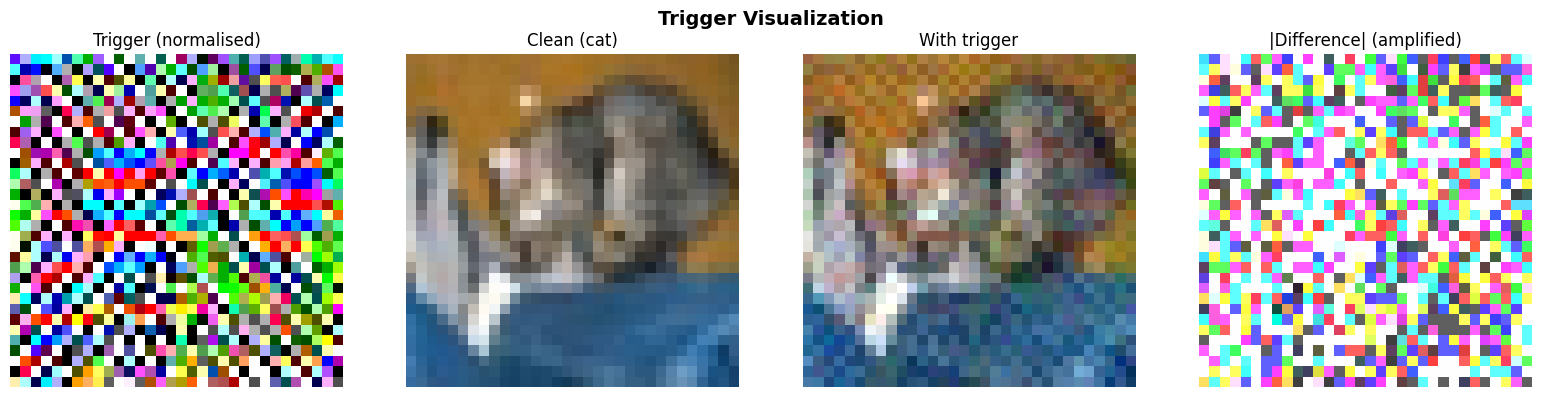

Saved: /content/drive/MyDrive/ps-capstone/sk/results/silentkiller_trigger_visualization.png


In [ ]:
# ── Trigger visualization (locked/shared trigger, or the pilot's if independent) ──
_trigger_for_viz = (np.load(trigger_path(PILOT_PR_TAG, 'shared')) if CRAFTING_POLICY == 'shared'
                    else np.load(trigger_path('pr01', 'independent')))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

trigger_np = _trigger_for_viz.transpose(1, 2, 0) if _trigger_for_viz.shape[0] == 3 else _trigger_for_viz
trigger_disp = (trigger_np - trigger_np.min()) / (trigger_np.max() - trigger_np.min() + 1e-8)
axes[0].imshow(trigger_disp)
axes[0].set_title('Trigger (normalised)')
axes[0].axis('off')

_src_idx = [i for i, (_, y) in enumerate(dataset_test) if y == SOURCE_LABEL][0]
_clean_img, _ = dataset_test[_src_idx]
axes[1].imshow(_clean_img.numpy().transpose(1, 2, 0))
axes[1].set_title(f'Clean ({dataset_test.classes[SOURCE_LABEL]})')
axes[1].axis('off')

_trig_injector = TriggerAdditive(size=dataset_train[0][0].shape, sigma=0.01)
_trig_injector.update_trigger(torch.tensor(_trigger_for_viz))
_triggered_img = _trig_injector.inject(_clean_img.clone())
axes[2].imshow(_triggered_img.detach().numpy().transpose(1, 2, 0))
axes[2].set_title('With trigger')
axes[2].axis('off')

_diff = np.abs(_triggered_img.detach().numpy() - _clean_img.numpy()).transpose(1, 2, 0)
_diff_amp = _diff / (_diff.max() + 1e-8)
axes[3].imshow(_diff_amp)
axes[3].set_title('|Difference| (amplified)')
axes[3].axis('off')

plt.suptitle('Trigger Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
_trig_path_viz = str(Path(RESULTS_DIR) / 'silentkiller_trigger_visualization.png')
plt.savefig(_trig_path_viz, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_trig_path_viz}')

In [ ]:
# ── Clean vs. poisoned sample visualization (pr01, i.e. the pilot rate) ──
_pix_path_viz = poisoned_pixels_path('pr01')
if not Path(_pix_path_viz).exists():
    print('[SKIP] No saved poisoned-pixels file found for pr01. '
          'Run Section 14 with fresh crafting (not a cache-hit) to generate it.')
else:
    _poisoned_pixels = np.load(_pix_path_viz)
    _poison_idx = main_sweep_results['pr01']['poison_idx']
    n_show = min(5, len(_poison_idx))
    fig, axes = plt.subplots(3, n_show, figsize=(3 * n_show, 9))

    for i in range(n_show):
        idx = _poison_idx[i]
        clean_img, label = dataset_train[idx]
        poisoned_img = _poisoned_pixels[i]

        axes[0, i].imshow(clean_img.numpy().transpose(1, 2, 0))
        axes[0, i].set_title(f'Clean #{idx}\n({dataset_train.classes[label]})')
        axes[0, i].axis('off')

        axes[1, i].imshow(poisoned_img.transpose(1, 2, 0))
        axes[1, i].set_title(f'Poisoned #{idx}')
        axes[1, i].axis('off')

        diff = np.abs(poisoned_img - clean_img.numpy()).transpose(1, 2, 0)
        diff_amp = diff / (diff.max() + 1e-8)
        axes[2, i].imshow(diff_amp)
        axes[2, i].set_title('|Diff| (amplified)')
        axes[2, i].axis('off')

    plt.suptitle('Clean vs Poisoned Samples (pr01)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    _ps_path = str(Path(RESULTS_DIR) / 'silentkiller_poisoned_samples.png')
    plt.savefig(_ps_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {_ps_path}')

[SKIP] No saved poisoned-pixels file found for pr01. Run Section 14 with fresh crafting (not a cache-hit) to generate it.


---
## Section 22 — Closing Notes / Locked Decisions

Required closing cell per §3 of `silentkiller_required_fixes_v2.md`, so a
future handoff doc (mirroring `blended_stage_C_status.md`) can be written
without re-deriving anything below.

In [ ]:
# ── Locked-decisions record ────────────────────────────────────────────────
locked_decisions = {
    'seed': SEED,
    'target_class': {'label': TARGET_LABEL, 'name': dataset_test.classes[TARGET_LABEL]},
    'source_class': {'label': SOURCE_LABEL, 'name': dataset_test.classes[SOURCE_LABEL]},
    'trigger_variant': TRIGGER_TYPE,   # 'additive' -- confirmed correct, unchanged
    'trigger_eps': EPS,
    'dr_method_choice': 'NOT YET LOCKED -- see silentkiller_dr_comparison.csv, decide '
                         'PCA-2D vs. ICA-10D the same way it was decided for Blended '
                         '(05_DETECTION_AND_VERIFICATION.md, "Per-attack DR choice")',
    'clean_source_model_decision': (
        'RESOLVED: two separate checkpoints, mirroring the Label-Consistent resolution. '
        f'Canonical baseline = {CLEAN_BASELINE_CKPT} (shared, pipeline-wide). '
        f'SK clean-source = {CLEAN_SOURCE_CKPT} (crafting-only, never used downstream).'
    ),
    'decision_1_crafting_policy': {
        'outcome': CRAFTING_POLICY,
        'pilot_pr_tag': PILOT_PR_TAG,
        'pilot_asr': pilot_asr,
        'pilot_ca': pilot_ca,
        'gate_threshold': PILOT_ASR_GATE_THRESHOLD,
        'reasoning': (
            f'Pilot ASR ({pilot_asr:.4f}) '
            + ('>= ' if pilot_asr >= PILOT_ASR_GATE_THRESHOLD else '< ')
            + f'threshold ({PILOT_ASR_GATE_THRESHOLD:.0%}) -> '
            + ('locked Option A (shared trigger across all rates).' if CRAFTING_POLICY == 'shared'
               else 'fell back to Option B (independent per-rate trigger + ranking); '
                    'nesting property does NOT hold across rates for this run.')
        ),
    },
    'poison_rates_run': POISON_RATES,
    'lowrate_counts_run': LOWRATE_COUNTS,
    'decision_2_tar_substitute': (
        'Attention Correlation (Pearson correlation of clean vs. triggered Grad-CAM '
        'heatmaps) used in place of TAR, since the global additive trigger has no '
        'bounding box. Pre-defense baseline only -- see silentkiller_gradcam_attncorr.csv.'
    ),
    'decision_3_poison_rate_scope': (
        '0.5% poison rate added for Silent Killer only, not retrofitted onto BadNets/Blended.'
    ),
    'clean_label_poisoning_note': (
        'Silent Killer poisons TARGET-class images only (clean-label, like LC) via '
        'gradient-based selection. Its nominal poison-rate percentages are therefore '
        'fractions of the full 50k training set, and at 10% this equals the ENTIRE '
        'target class (5,000/5,000 airplane images) -- the same framing caveat noted '
        'for LC in 00_PROJECT_MASTER.md applies here.'
    ),
    'timestamp': datetime.datetime.now().isoformat(),
}

print('=' * 70)
print('  LOCKED DECISIONS -- SILENT KILLER')
print('=' * 70)
print(json.dumps(locked_decisions, indent=2, default=str))

_locked_path = f'{DRIVE_ROOT}/silentkiller_locked_decisions.json'
with open(_locked_path, 'w') as _f:
    json.dump(locked_decisions, _f, indent=2, default=str)
print(f'\nSaved: {_locked_path}')
print('\nThis is the record a future handoff doc (mirroring blended_stage_C_status.md)')
print('should read first -- it captures every decision this notebook made, not just what')
print('was run.')

  LOCKED DECISIONS -- SILENT KILLER
{
  "seed": 2027,
  "target_class": {
    "label": 0,
    "name": "airplane"
  },
  "source_class": {
    "label": 3,
    "name": "cat"
  },
  "trigger_variant": "additive",
  "trigger_eps": 0.062745,
  "dr_method_choice": "NOT YET LOCKED -- see silentkiller_dr_comparison.csv, decide PCA-2D vs. ICA-10D the same way it was decided for Blended (05_DETECTION_AND_VERIFICATION.md, \"Per-attack DR choice\")",
  "clean_source_model_decision": "RESOLVED: two separate checkpoints, mirroring the Label-Consistent resolution. Canonical baseline = /content/drive/MyDrive/ps-capstone/sk/resnet18_clean_seed2027.pth (shared, pipeline-wide). SK clean-source = /content/drive/MyDrive/ps-capstone/sk/silentkiller_clean_source_seed2027.pth (crafting-only, never used downstream).",
  "decision_1_crafting_policy": {
    "outcome": "shared",
    "pilot_pr_tag": "pr01",
    "pilot_asr": 0.901,
    "pilot_ca": 0.9184,
    "gate_threshold": 0.5,
    "reasoning": "Pilot ASR (0.90